# Raman Spectroscopy — PCA + Bagging SVM Classification Pipeline

**Project:** Proof-of-concept solvent classification pipeline, built as a precursor to ABO blood group typing from Raman spectra (Jensen et al. 2024). Blood samples not yet available; four structurally similar pharmaceutical solvents are used as a substitute dataset to validate the pipeline design.

**Classification strategy:** Pairwise binary (one-vs-one) — one SVM trained per solvent pair, giving 6 classifiers for 4 classes. This mirrors the ABO typing structure.

**Pipeline:** PCA (dimensionality reduction, fit on training data only) → Bagging ensemble of 50 SVMs.

**Dataset:** Flanagan & Glavin (2025), *Scientific Data* — 428 spectra, 4 solvents (Ethyl Acetate, Propyl Acetate, Butyl Acetate, Methyl Isobutyl Ketone), 200–1800 cm⁻¹, Endress+Hauser Raman Rxn2 (785 nm excitation). Preprocessed via `Solvent_preprocessing.ipynb` (baseline correction + SNV normalisation).

**Method adapted from:** Jensen et al. (2024), *Advanced Materials Technologies.*

---

**Notebook structure:**
1. Config — all paths and hyperparameters in one place
2. Load preprocessed data
3. Train / test split — block holdout
4. PCA + Bagging SVM pipeline
5. Train & evaluate all 6 pairwise classifiers
6. Plots — confusion matrices, precision-recall, PC loadings
7. Validation — permutation test + swap test
8. Robustness tests — noise, label corruption, feature zeroing, shift
9. Shift tolerance sweep — inference-time robustness
10. Shift diagnostics — why the model breaks and what drives the fluctuation
11. Raw spectra — load and visual inspection
12. Raw spectra test — clean model tested on raw data
13. Raw pipeline — train and evaluate entirely on raw data


## 0. Imports

In [31]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold 
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.utils import shuffle as sk_shuffle

## 1. Config

All paths and hyperparameters are defined here. **Only edit this cell** when adapting the pipeline to new data or instruments.

In [32]:
# --- Paths ---
CLEAN_CSV = "/Users/dons/Library/Mobile Documents/com~apple~CloudDocs/ZHAW/SS26/Track 2/Raman Solvents/raman_spectra_clean.csv"
RAW_CSV   = "/Users/dons/Library/Mobile Documents/com~apple~CloudDocs/ZHAW/SS26/Track 2/Raman Solvents/raman_spectra_api_compounds.csv"

# --- Classes ---
TARGETS = ['Ethyl Acetate', 'Propyl acetate', 'Butyl Acetate', 'Methyl Isobutyl Ketone']
COLORS  = ['steelblue', 'darkorange', 'green', 'crimson']

# --- Wavenumber crop (must match preprocessing) ---
CROP_MIN = 200
CROP_MAX = 1800  # cm⁻¹

# --- SVM hyperparameters ---
N_ESTIMATORS = 50    # number of SVMs in the bag
MAX_SAMPLES  = 0.8   # bootstrap subset size
SVM_C        = 1
SVM_GAMMA    = 'scale'
RANDOM_STATE = 42

# --- Validation ---
N_PERMUTATIONS = 100  # permutation test runs

# --- Shift tolerance sweep ---
SHIFT_STEPS = [0, 1, 2, 5, 10, 20, 30, 40, 50, 60, 75, 100, 1700]

## 2. Load Preprocessed Data

Loads the SNV-normalised, baseline-corrected spectra produced by `Solvent_preprocessing.ipynb`. Each row is one spectrum; columns are wavenumber positions (200–1800 cm⁻¹); the final column is the class label.

In [33]:
df = pd.read_csv(CLEAN_CSV)

X = df.drop(columns=['label']).values.astype(float)
y = df['label'].values
wavenumbers = df.drop(columns=['label']).columns.astype(float).values

print(f"Loaded {X.shape[0]} spectra × {X.shape[1]} wavenumbers")
print(f"Wavenumber range: {wavenumbers[0]:.0f} – {wavenumbers[-1]:.0f} cm⁻¹")
print(f"Class counts: { {g: int((y == g).sum()) for g in np.unique(y)} }")

Loaded 428 spectra × 1601 wavenumbers
Wavenumber range: 200 – 1800 cm⁻¹
Class counts: {'Butyl Acetate': 106, 'Ethyl Acetate': 110, 'Methyl Isobutyl Ketone': 105, 'Propyl acetate': 107}


## 3. Train / Test Split

**Block holdout:** every 5th spectrum per class is held out as test (indices 0, 5, 10, ...). This spreads the holdout evenly across the full acquisition session rather than concentrating it at the start or end, reducing the risk that session-level drift contaminates the evaluation.

The split is applied globally. Each pairwise classifier then subsets this global mask to its two classes.

In [34]:
# Assign each spectrum a within-class index (0, 1, 2, ...) based on its position in the CSV
# Assumes rows are ordered by acquisition time per class
df['sample_idx'] = df.groupby('label').cumcount()

# Every 5th spectrum per class becomes a test sample (indices 0, 5, 10, ...)
# This spreads the holdout evenly across the measurement session (block holdout)
test_mask = (df['sample_idx'] % 5 == 0).values  # boolean array, True = test

print(f"Train: {(~test_mask).sum()} spectra")
print(f"Test:  {test_mask.sum()} spectra")

# Build all pairwise combinations from TARGETS, filtered to classes
# actually present in the data (guards against missing labels in the CSV)
available = np.unique(y)
pairs     = [(c1, c2) for c1, c2 in combinations(TARGETS, 2)
             if c1 in available and c2 in available]

print(f"\n{len(pairs)} pairwise classifiers: {pairs}")

Train: 341 spectra
Test:  87 spectra

6 pairwise classifiers: [('Ethyl Acetate', 'Propyl acetate'), ('Ethyl Acetate', 'Butyl Acetate'), ('Ethyl Acetate', 'Methyl Isobutyl Ketone'), ('Propyl acetate', 'Butyl Acetate'), ('Propyl acetate', 'Methyl Isobutyl Ketone'), ('Butyl Acetate', 'Methyl Isobutyl Ketone')]


/var/folders/y9/r90ymhc97xl7p3sz2tfbcspm0000gn/T/ipykernel_97811/614601085.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['sample_idx'] = df.groupby('label').cumcount()


## 4. PCA + Bagging SVM Pipeline

**PCA:** fitted on training data only to prevent leakage. Number of components selected to capture 99.99% of training variance, capped at `(min_pair_train_size − 2)` so PCA never requests more components than there are training samples in the smallest pair.

**Bagging SVM:** 50 SVMs, each trained on an 80% bootstrap subset of the training data. Averaging over 50 models reduces variance and produces more stable probability estimates — particularly valuable on small datasets (Jensen et al. 2024).

The PCA and SVM are chained into a single `Pipeline` object so that `fit()` fits PCA on training data then passes the reduced representations to the SVM, and `predict()` applies the same PCA transform before predicting. This prevents any leakage through the transform step.

PCs for 95.00% variance : 3
PCs for 99.00% variance : 5
PCs for 99.99% variance : 42
N_PCA selected          : 42


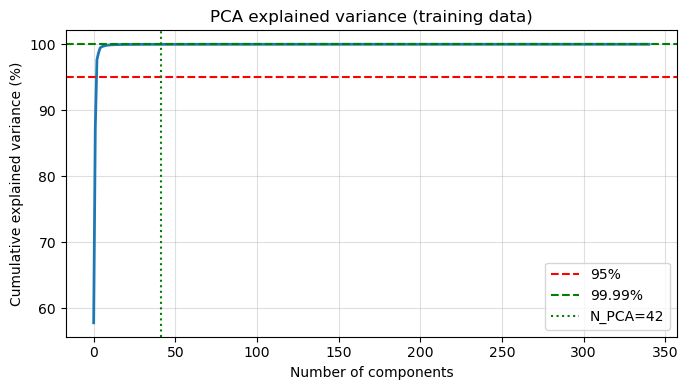

In [35]:
# --- Determine N_PCA from training data ---

# Fit PCA on training data only (test set excluded to prevent leakage)
X_train_all = X[~test_mask]
_pca_full   = PCA().fit(X_train_all)

# Cumulative explained variance ratio
_cumvar = np.cumsum(_pca_full.explained_variance_ratio_)

# Find the smallest pairwise training set across all 6 pairs.
# N_PCA is capped at (min_pair_train - 2) to ensure PCA never requests
# more components than there are training samples in the smallest pair.
min_pair_train = min(
    int(np.isin(y[~test_mask], [c1, c2]).sum()) for c1, c2 in pairs
)

# Select N_PCA as whichever is smaller:
#   - the number of PCs needed to capture 99.99% of training variance, OR
#   - (smallest pairwise training set - 2), to stay within PCA's valid range
N_PCA = min(int(np.searchsorted(_cumvar, 0.9999)) + 1, min_pair_train - 2)

print(f"PCs for 95.00% variance : {int(np.searchsorted(_cumvar, 0.95)) + 1}")
print(f"PCs for 99.00% variance : {int(np.searchsorted(_cumvar, 0.99)) + 1}")
print(f"PCs for 99.99% variance : {int(np.searchsorted(_cumvar, 0.9999)) + 1}")
print(f"N_PCA selected          : {N_PCA}")

# Plot cumulative explained variance curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(_cumvar * 100, lw=2)
ax.axhline(95,    color='red',   linestyle='--', label='95%')
ax.axhline(99.99, color='green', linestyle='--', label='99.99%')
ax.axvline(N_PCA - 1, color='green', linestyle=':', label=f'N_PCA={N_PCA}')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA explained variance (training data)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [36]:
# --- Build pipeline template ---

base_svm = SVC(
    kernel='rbf',
    probability=True,        # enables predict_proba(), needed for AUC scoring
    class_weight='balanced', # compensates for any class imbalance per pair
    C=SVM_C,
    gamma=SVM_GAMMA,
)

bagging_svm = BaggingClassifier(
    estimator=base_svm,
    n_estimators=N_ESTIMATORS,  # 50 SVMs per ensemble
    max_samples=MAX_SAMPLES,    # each SVM sees 80% of training data
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Chain PCA and BaggingSVM into a single pipeline.
# fit() → fits PCA on X_tr, transforms, then fits SVM on PCA output.
# predict() → applies the same PCA transform before predicting.
pipe = Pipeline([
    ('pca', PCA(n_components=N_PCA)),
    ('svm', bagging_svm),
])

print(f"Pipeline ready: PCA({N_PCA}) → BaggingSVM(n={N_ESTIMATORS})")

Pipeline ready: PCA(42) → BaggingSVM(n=50)


## 5. Train & Evaluate All 6 Pairwise Classifiers

Each pair is trained independently. Results are stored in `fitted_models` (keyed by pair label) for use in later sections.

**Metrics:**
- **AUC-ROC** — area under the ROC curve; 1.0 = perfect separation, 0.5 = chance
- **Balanced accuracy (BA)** — mean of per-class recall; robust to class imbalance

In [37]:
# Storage for metrics and trained models across all 6 pairs
results       = {}   # {label: {'AUC': ..., 'BA': ...}}
fitted_models = {}   # {label: (model, X_te, y_te, y_pred, y_prob, cls1, cls2)}

# Repeated stratified 5-fold CV — matches Jensen et al. (2024).
# 5 splits × 10 repeats = 50 evaluations per pair.
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

for cls1, cls2 in pairs:
    label = f"{cls1} vs {cls2}"

    # Subset to this pair; binary encode (cls1 = 1, cls2 = 0)
    mask   = np.isin(y, [cls1, cls2])
    X_pair = X[mask]
    y_bin  = (y[mask] == cls1).astype(int)

    print(f"Evaluating: {label}  (n={len(y_bin)})")

    fold_splits   = list(rskf.split(X_pair, y_bin))
    auc_scores_cv = []
    ba_scores_cv  = []

    for fold, (train_idx, test_idx) in enumerate(fold_splits):
        X_tr, X_te = X_pair[train_idx], X_pair[test_idx]
        y_tr, y_te = y_bin[train_idx],  y_bin[test_idx]

        # N_PCA recomputed per fold from THIS fold's training data only (no leakage)
        _pca_fold  = PCA().fit(X_tr)
        _cumvar    = np.cumsum(_pca_fold.explained_variance_ratio_)
        n_pca_fold = min(int(np.searchsorted(_cumvar, 0.9999)) + 1, len(X_tr) - 2)

        fold_pipe = clone(pipe).set_params(pca__n_components=n_pca_fold)
        fold_pipe.fit(X_tr, y_tr)

        y_prob = fold_pipe.predict_proba(X_te)[:, 1]
        y_pred = fold_pipe.predict(X_te)

        auc_scores_cv.append(roc_auc_score(y_te, y_prob))
        ba_scores_cv.append(balanced_accuracy_score(y_te, y_pred))

        # Keep the LAST fold's model + its test set for Sections 6–13 diagnostics.
        # Stored in the exact same 7-tuple format as the original block-holdout version.
        if fold == len(fold_splits) - 1:
            fitted_models[label] = (fold_pipe, X_te, y_te, y_pred, y_prob, cls1, cls2)

    mean_auc, std_auc = np.mean(auc_scores_cv), np.std(auc_scores_cv)
    mean_ba,  std_ba  = np.mean(ba_scores_cv),  np.std(ba_scores_cv)

    results[label] = {'AUC': mean_auc, 'BA': mean_ba,
                      'AUC_str': f"{mean_auc:.2f} ± {std_auc:.2f}",
                      'BA_str':  f"{mean_ba:.2f} ± {std_ba:.2f}"}

    print(f"  AUC = {mean_auc:.3f} ± {std_auc:.3f}")
    print(f"  BA  = {mean_ba:.3f}  ± {std_ba:.3f}\n")

# Summary table — Jensen et al. format (mean ± std over 50 folds)
summary = pd.DataFrame({label: {'AUC': results[label]['AUC_str'],
                                'BA':  results[label]['BA_str']}
                        for label in results}).T
print("\n--- Summary (mean ± std over 50 folds) ---")
print(summary)

Evaluating: Ethyl Acetate vs Propyl acetate  (n=217)
  AUC = 1.000 ± 0.000
  BA  = 1.000  ± 0.000

Evaluating: Ethyl Acetate vs Butyl Acetate  (n=216)
  AUC = 1.000 ± 0.000
  BA  = 1.000  ± 0.000

Evaluating: Ethyl Acetate vs Methyl Isobutyl Ketone  (n=215)
  AUC = 1.000 ± 0.000
  BA  = 1.000  ± 0.000

Evaluating: Propyl acetate vs Butyl Acetate  (n=213)
  AUC = 1.000 ± 0.000
  BA  = 1.000  ± 0.000

Evaluating: Propyl acetate vs Methyl Isobutyl Ketone  (n=212)
  AUC = 1.000 ± 0.000
  BA  = 1.000  ± 0.000

Evaluating: Butyl Acetate vs Methyl Isobutyl Ketone  (n=211)
  AUC = 1.000 ± 0.000
  BA  = 1.000  ± 0.000


--- Summary (mean ± std over 50 folds) ---
                                                  AUC           BA
Ethyl Acetate vs Propyl acetate           1.00 ± 0.00  1.00 ± 0.00
Ethyl Acetate vs Butyl Acetate            1.00 ± 0.00  1.00 ± 0.00
Ethyl Acetate vs Methyl Isobutyl Ketone   1.00 ± 0.00  1.00 ± 0.00
Propyl acetate vs Butyl Acetate           1.00 ± 0.00  1.00 ± 0.00
Pro

## 6. Plots — Confusion Matrices, Precision-Recall, PC Loadings

Three panels per pair:
- **Confusion matrix** — shows actual vs predicted class counts
- **Precision-recall curve** — summarised by average precision (AP); useful when class balance matters
- **PC loadings (top 3)** — the wavenumber regions that drive variance in PCA space; peaks here correspond to real Raman bands and confirm the model is responding to chemistry, not noise

A combined confusion matrix grid for all 6 pairs is shown at the end for a compact overview.

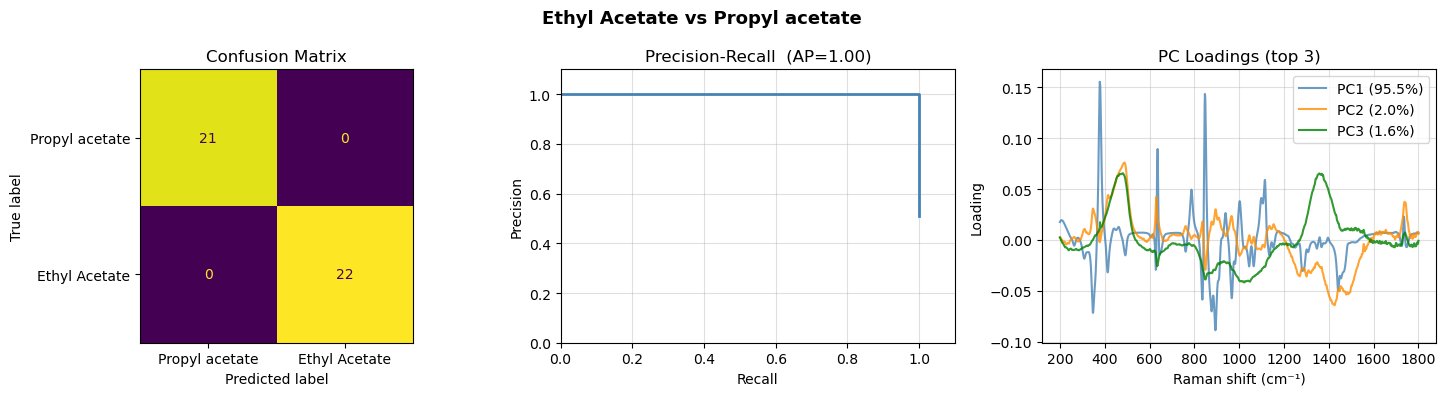

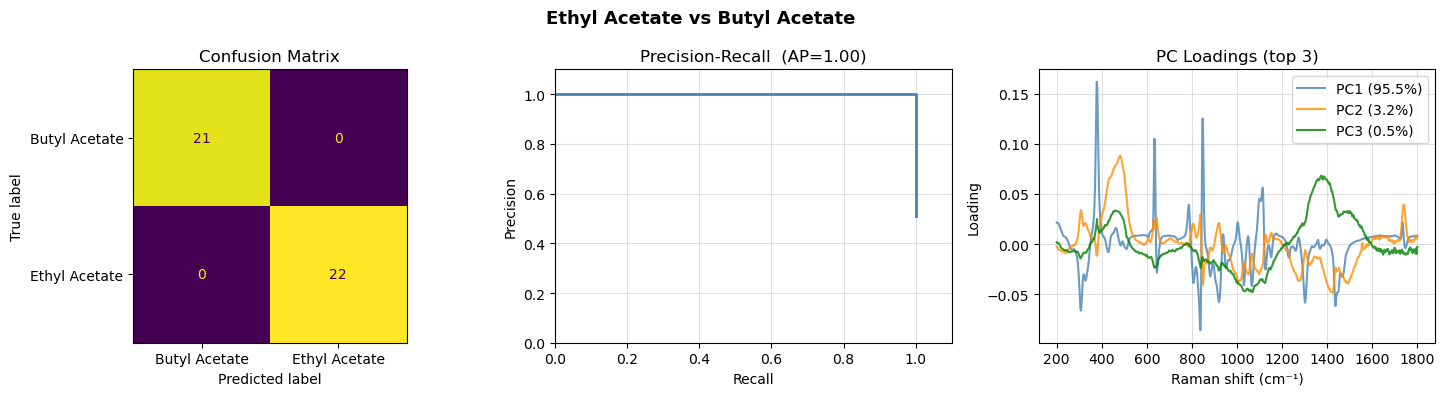

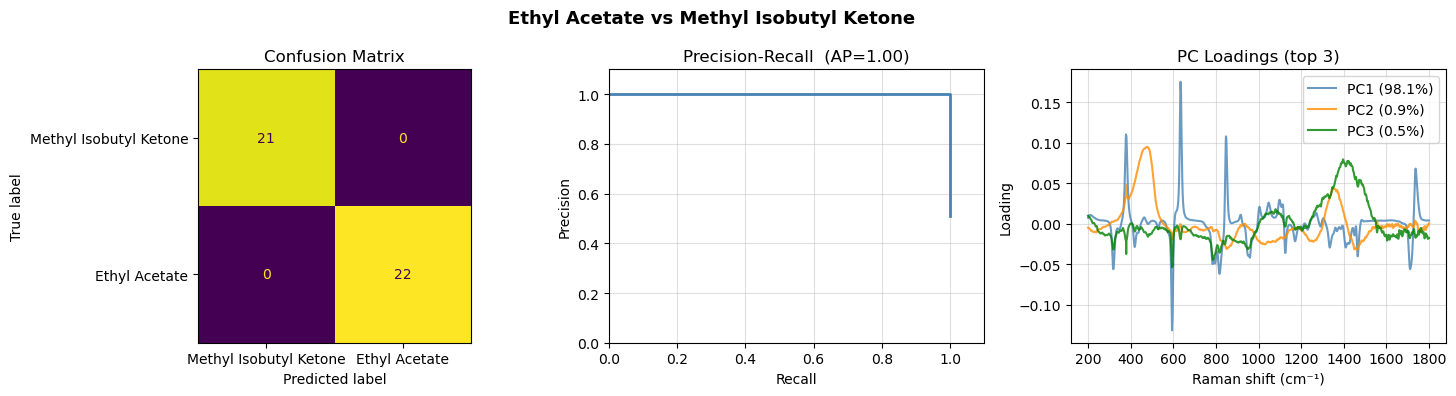

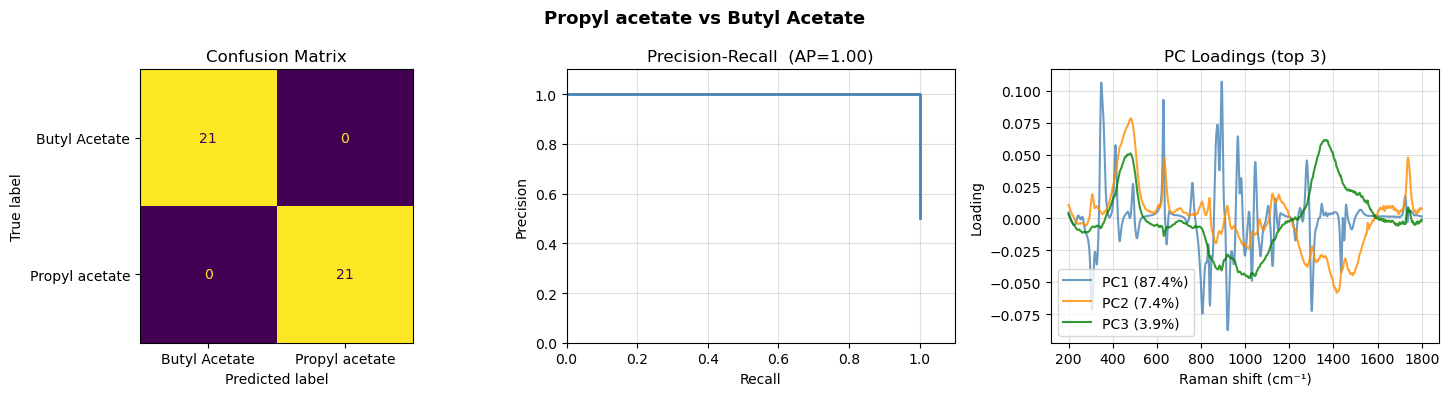

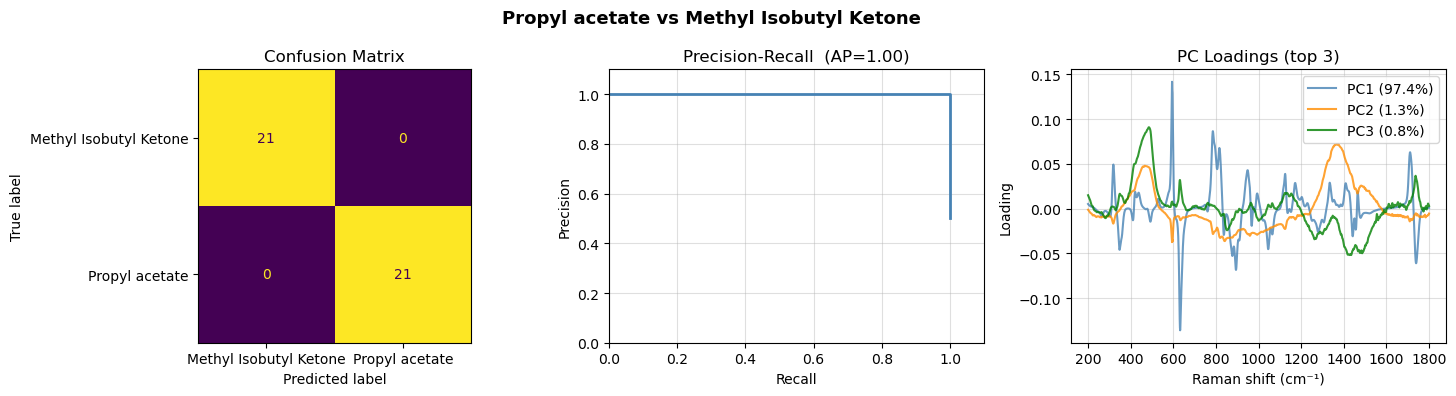

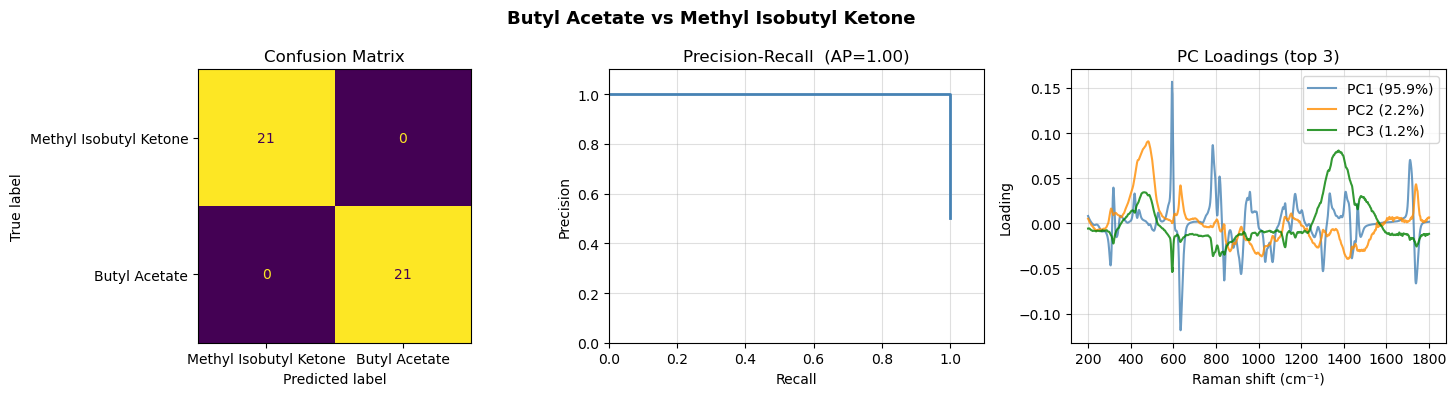

In [38]:
# One figure per pair: confusion matrix, precision-recall curve, PC loadings
for label, (model, X_te, y_te, y_pred, y_prob, cls1, cls2) in fitted_models.items():

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(label, fontsize=13, fontweight='bold')

    # --- Panel 1: Confusion Matrix ---
    cm   = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[cls2, cls1])
    disp.plot(ax=axes[0], colorbar=False)
    axes[0].set_title('Confusion Matrix')

    # --- Panel 2: Precision-Recall Curve ---
    precision, recall, _ = precision_recall_curve(y_te, y_prob)
    ap = average_precision_score(y_te, y_prob)
    axes[1].plot(recall, precision, color='steelblue', lw=2)
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'Precision-Recall  (AP={ap:.2f})')
    axes[1].set_xlim([0, 1.1])
    axes[1].set_ylim([0, 1.1])
    axes[1].grid(True, alpha=0.4)

    # --- Panel 3: PC Loadings (top 3 components) ---
    # Peaks in the loading plot correspond to chemically meaningful Raman bands
    # that drive the separation between the two classes.
    pca_step = model.named_steps['pca']
    n_pcs    = min(3, pca_step.n_components_)
    for i, color in zip(range(n_pcs), ['steelblue', 'darkorange', 'green']):
        axes[2].plot(
            wavenumbers, pca_step.components_[i],
            color=color, alpha=0.8,
            label=f"PC{i+1} ({pca_step.explained_variance_ratio_[i]*100:.1f}%)",
        )
    axes[2].set_xlabel('Raman shift (cm⁻¹)')
    axes[2].set_ylabel('Loading')
    axes[2].set_title('PC Loadings (top 3)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

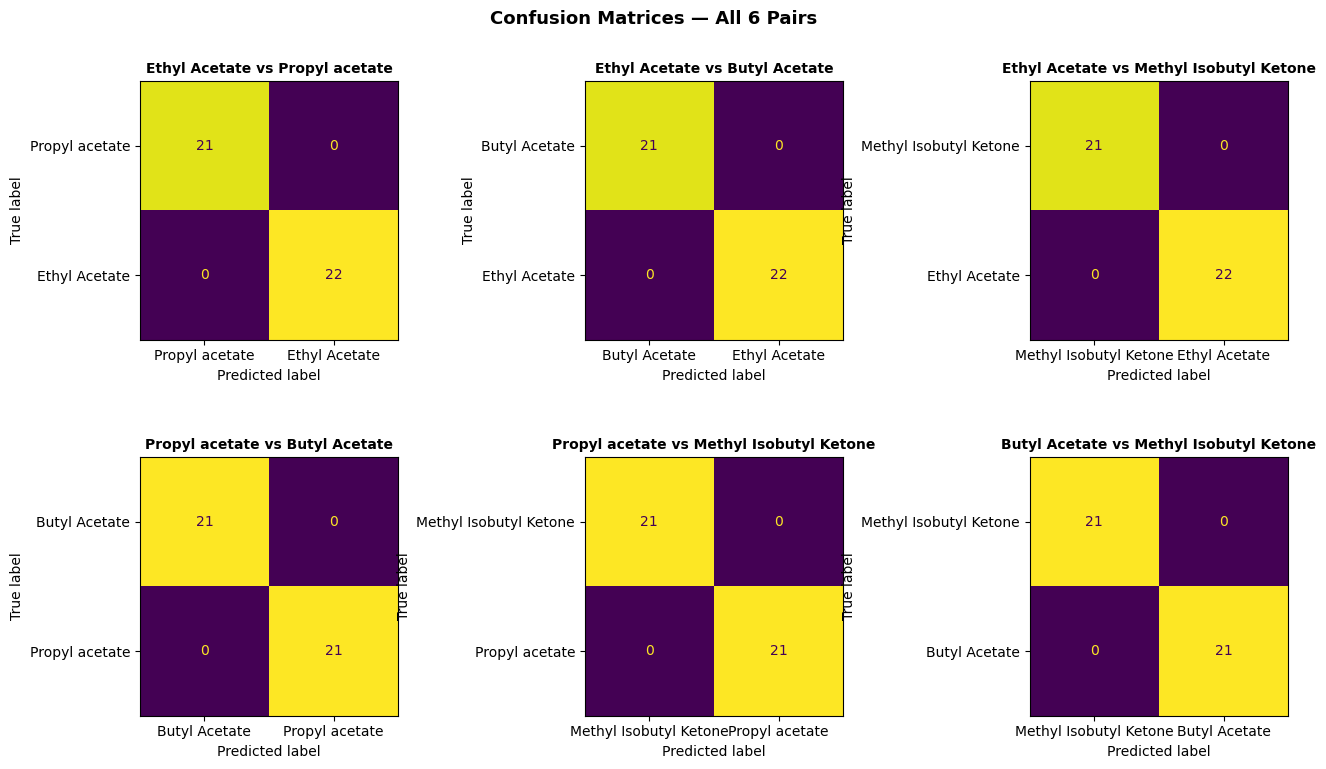

In [39]:
# --- Confusion matrices — all 6 pairs in one figure ---
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, (label, (model, X_te, y_te, y_pred, y_prob, cls1, cls2)) in zip(axes, fitted_models.items()):
    cm   = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[cls2, cls1])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(label, fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — All 6 Pairs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Validation

Two complementary checks that the model has learned real chemical signal rather than overfitting or lucky splits.

### 7a. Permutation Test (100 runs)

Training labels are randomly shuffled 100 times; a fresh model is trained each time. If the model learns genuine signal, AUC should collapse to ~0.5 under permutation. A large gap between real AUC and permuted AUC confirms the result is not a statistical artefact.

**Expected outcome:** permuted AUC ≈ 0.50 ± small std.

In [40]:
print(f"Running {N_PERMUTATIONS} permutation runs per pair...\n")

for cls1, cls2 in pairs:
    mask       = np.isin(y, [cls1, cls2])
    X_pair     = X[mask]
    y_bin      = (y[mask] == cls1).astype(int)
    block_test = test_mask[mask]
    X_tr, X_te = X_pair[~block_test], X_pair[block_test]
    y_tr, y_te = y_bin[~block_test],  y_bin[block_test]

    perm_aucs = []
    for i in range(N_PERMUTATIONS):
        # Shuffle only training labels — breaks spectrum-class relationship.
        # Any AUC above 0.5 in the real model must come from genuine signal.
        y_tr_perm = sk_shuffle(y_tr, random_state=i)
        p = clone(pipe)
        p.fit(X_tr, y_tr_perm)
        perm_aucs.append(roc_auc_score(y_te, p.predict_proba(X_te)[:, 1]))

    label = f"{cls1} vs {cls2}"
    print(f"{label}")
    print(f"  Real AUC     : {results[label]['AUC']:.3f}")
    print(f"  Permuted AUC : {np.mean(perm_aucs):.3f} ± {np.std(perm_aucs):.3f}\n")

Running 100 permutation runs per pair...

Ethyl Acetate vs Propyl acetate
  Real AUC     : 1.000
  Permuted AUC : 0.526 ± 0.365

Ethyl Acetate vs Butyl Acetate
  Real AUC     : 1.000
  Permuted AUC : 0.496 ± 0.382

Ethyl Acetate vs Methyl Isobutyl Ketone
  Real AUC     : 1.000
  Permuted AUC : 0.494 ± 0.418

Propyl acetate vs Butyl Acetate
  Real AUC     : 1.000
  Permuted AUC : 0.526 ± 0.349

Propyl acetate vs Methyl Isobutyl Ketone
  Real AUC     : 1.000
  Permuted AUC : 0.534 ± 0.387

Butyl Acetate vs Methyl Isobutyl Ketone
  Real AUC     : 1.000
  Permuted AUC : 0.526 ± 0.402



### 7b. Swap Test

Train on the small held-out test set, evaluate on the large training set — the reverse of the normal split. If the signal is symmetric and not tied to specific samples, AUC should remain high. This rules out the possibility that results are driven by a few outlier spectra that happen to dominate the test set.

In [41]:
print("Swap test (train on test set, evaluate on train set):\n")

for cls1, cls2 in pairs:
    mask       = np.isin(y, [cls1, cls2])
    X_pair     = X[mask]
    y_bin      = (y[mask] == cls1).astype(int)
    block_test = test_mask[mask]
    X_tr, X_te = X_pair[~block_test], X_pair[block_test]
    y_tr, y_te = y_bin[~block_test],  y_bin[block_test]

    # X_te is ~5x smaller than X_tr — cap n_components to keep PCA valid
    n_swap    = min(N_PCA, len(X_te) - 2)
    swap_pipe = clone(pipe).set_params(pca__n_components=n_swap)

    swap_pipe.fit(X_te, y_te)
    auc_swap = roc_auc_score(y_tr, swap_pipe.predict_proba(X_tr)[:, 1])
    print(f"{cls1} vs {cls2}:  swapped AUC = {auc_swap:.3f}  (n_swap={n_swap}, test_size={len(X_te)})")

Swap test (train on test set, evaluate on train set):

Ethyl Acetate vs Propyl acetate:  swapped AUC = 1.000  (n_swap=42, test_size=44)
Ethyl Acetate vs Butyl Acetate:  swapped AUC = 1.000  (n_swap=42, test_size=44)
Ethyl Acetate vs Methyl Isobutyl Ketone:  swapped AUC = 1.000  (n_swap=41, test_size=43)
Propyl acetate vs Butyl Acetate:  swapped AUC = 1.000  (n_swap=42, test_size=44)
Propyl acetate vs Methyl Isobutyl Ketone:  swapped AUC = 1.000  (n_swap=41, test_size=43)
Butyl Acetate vs Methyl Isobutyl Ketone:  swapped AUC = 1.000  (n_swap=41, test_size=43)


## 8. Robustness Tests — Training-Time Corruption

A fresh model is trained on corrupted training data and evaluated on the original clean test set. This answers: **how stable is the training process under realistic data quality issues?**

Corruptions tested:
- **Label shuffle 30%** — 30% of training labels randomly reassigned; simulates annotation errors
- **Gaussian noise 10 dB** — additive noise at signal-to-noise ratio of 10 dB
- **Feature zeroing 10%** — 10% of spectral values randomly set to zero; simulates detector dropouts
- **Spectral shift +5 wn** — training spectra shifted by 5 wavenumber steps; simulates instrument misalignment at training time
- **Class collapse** — Propyl acetate relabelled as Ethyl Acetate; tests whether merged similar classes still allow the remaining pairs to classify

Note: the shift test here is a *training-time* test. The *inference-time* shift sweep (fixed model, shifted test data) is in Section 9.

In [42]:
# --- Corruption helpers ---

def corrupt_labels(y, frac=0.30, seed=42):
    """Force exactly frac of labels to a different class."""
    rng       = np.random.default_rng(seed)
    y_out     = y.copy()
    classes   = np.unique(y)
    n_corrupt = int(frac * len(y))
    idx       = rng.choice(len(y), size=n_corrupt, replace=False)
    for i in idx:
        other    = classes[classes != y_out[i]]
        y_out[i] = rng.choice(other)
    changed = int((y_out != y).sum())
    print(f"  Label shuffle: {changed}/{len(y)} = {changed/len(y)*100:.1f}% changed")
    return y_out

def add_noise(X, snr_db=10, seed=42):
    """Add Gaussian noise at a given SNR."""
    rng = np.random.default_rng(seed)
    noise_std = np.sqrt(np.mean(X**2) / 10**(snr_db / 10))
    return X + rng.normal(0, noise_std, X.shape)

def zero_features(X, frac=0.10, seed=42):
    """Randomly zero out frac of spectral values."""
    rng   = np.random.default_rng(seed)
    X_out = X.copy()
    X_out[rng.random(X.shape) < frac] = 0.0
    return X_out

def shift_spectra(X, steps):
    """Shift every spectrum by `steps` wavenumber positions (rightward).
    Vacated region is zero-padded — simulates wavenumber axis misalignment.
    """
    if steps == 0:
        return X.copy()
    X_out = np.roll(X, steps, axis=1)
    if steps > 0:
        X_out[:, :steps] = 0.0
    else:
        X_out[:, steps:] = 0.0
    return X_out

def mean_auc(X_tr_corrupt, y_tr_corrupt, pairs, X_clean, y_clean, test_mask, pipe):
    """Train on corrupted training data, evaluate on clean test set."""
    aucs = []
    for cls1, cls2 in pairs:
        mask       = np.isin(y_clean, [cls1, cls2])
        block_test = test_mask[mask]
        X_tr = X_tr_corrupt[mask][~block_test]
        y_tr = (y_tr_corrupt[mask][~block_test] == cls1).astype(int)
        X_te = X_clean[mask][block_test]
        y_te = (y_clean[mask][block_test] == cls1).astype(int)
        if len(np.unique(y_tr)) < 2:
            continue
        p = clone(pipe)
        p.fit(X_tr, y_tr)
        aucs.append(roc_auc_score(y_te, p.predict_proba(X_te)[:, 1]))
    return np.mean(aucs)

  Label shuffle: 128/428 = 29.9% changed
Clean                         mean AUC = 1.000
Label shuffle 30%             mean AUC = 1.000
Gaussian noise 10dB           mean AUC = 1.000
Feature zeroing 10%           mean AUC = 1.000
Spectral shift +5wn           mean AUC = 1.000
Class collapsed               mean AUC = 1.000


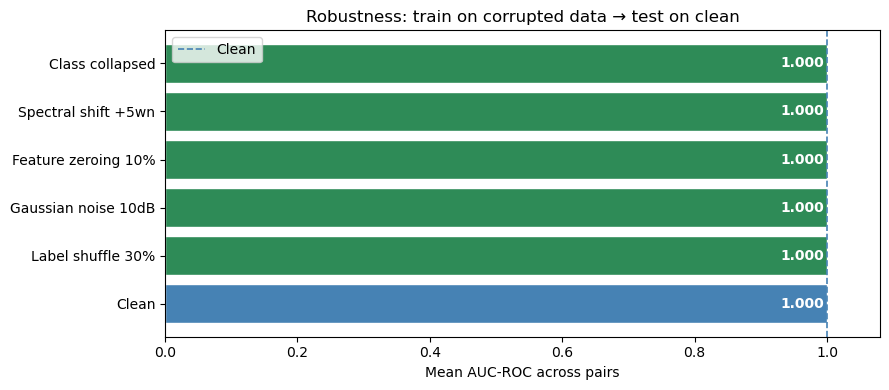

In [43]:
# --- Class collapse: merge Propyl acetate into Ethyl Acetate ---
# Simulates a systematic labelling error where two similar compounds are confused.
y_collapsed = np.where(y == 'Propyl acetate', 'Ethyl Acetate', y)
pairs_no_pa = [(c1, c2) for c1, c2 in pairs if 'Propyl acetate' not in (c1, c2)]

conditions = {
    'Clean':    (X,                       y,               pairs),
    'Label shuffle 30%':   (X,                       corrupt_labels(y, 0.30), pairs),
    'Gaussian noise 10dB': (add_noise(X, snr_db=10), y,               pairs),
    'Feature zeroing 10%': (zero_features(X, 0.10),  y,               pairs),
    'Spectral shift +5wn': (shift_spectra(X, 5),     y,               pairs),
    'Class collapsed':     (X,                       y_collapsed,     pairs_no_pa),
}

auc_scores = {}
for name, (X_c, y_c, pair_set) in conditions.items():
    score = mean_auc(X_c, y_c, pair_set, X, y, test_mask, pipe)
    auc_scores[name] = score
    print(f"{name:28s}  mean AUC = {score:.3f}")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(9, 4))
names  = list(auc_scores.keys())
scores = [auc_scores[n] for n in names]

colors = ['steelblue'] + ['seagreen' if v >= 0.95 else 'salmon' for v in scores[1:]]
bars   = ax.barh(names, scores, color=colors, edgecolor='white')

ax.axvline(auc_scores['Clean'], color='steelblue', linestyle='--',
           lw=1.2, label='Clean')

for bar, val in zip(bars, scores):
    ax.text(min(val - 0.005, 0.995), bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', ha='right', va='center', fontsize=10,
            color='white', fontweight='bold')

ax.set_xlabel('Mean AUC-ROC across pairs')
ax.set_title('Robustness: train on corrupted data → test on clean')
ax.set_xlim(0, 1.08)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Shift Tolerance Sweep — Inference-Time Robustness

The trained model is kept fixed. Only the test data is shifted by increasing wavenumber steps. This simulates the realistic deployment scenario where a model trained on one instrument or session receives spectra with a slight wavenumber axis misalignment.

**Key finding:** AUC = 1.0 for shifts up to 20 wn (the safe zone), then collapses sharply at 30 wn (the cliff). Beyond the cliff, AUC fluctuates between 0 and 0.5 before settling at exactly 0.5 at +1700 wn.

The cliff, the fluctuation, and the +1700 recovery are all explained mechanistically in Section 10.

In [44]:
# Shift tolerance sweep — fixed model, shifted test data
shift_aucs_fixed = {}

for s in SHIFT_STEPS:
    aucs = []
    for cls1, cls2 in pairs:
        label = f"{cls1} vs {cls2}"
        model, X_te, y_te, _, _, _, _ = fitted_models[label]
        X_te_shifted = shift_spectra(X_te, s)
        auc = roc_auc_score(y_te, model.predict_proba(X_te_shifted)[:, 1])
        aucs.append(auc)
    shift_aucs_fixed[s] = np.mean(aucs)
    print(f"Shift +{s:3d} wn  →  mean AUC = {np.mean(aucs):.3f}")

Shift +  0 wn  →  mean AUC = 1.000
Shift +  1 wn  →  mean AUC = 1.000
Shift +  2 wn  →  mean AUC = 1.000
Shift +  5 wn  →  mean AUC = 1.000
Shift + 10 wn  →  mean AUC = 1.000
Shift + 20 wn  →  mean AUC = 1.000
Shift + 30 wn  →  mean AUC = 0.167
Shift + 40 wn  →  mean AUC = 0.000
Shift + 50 wn  →  mean AUC = 0.000
Shift + 60 wn  →  mean AUC = 0.166
Shift + 75 wn  →  mean AUC = 0.281
Shift +100 wn  →  mean AUC = 0.172
Shift +1700 wn  →  mean AUC = 0.500


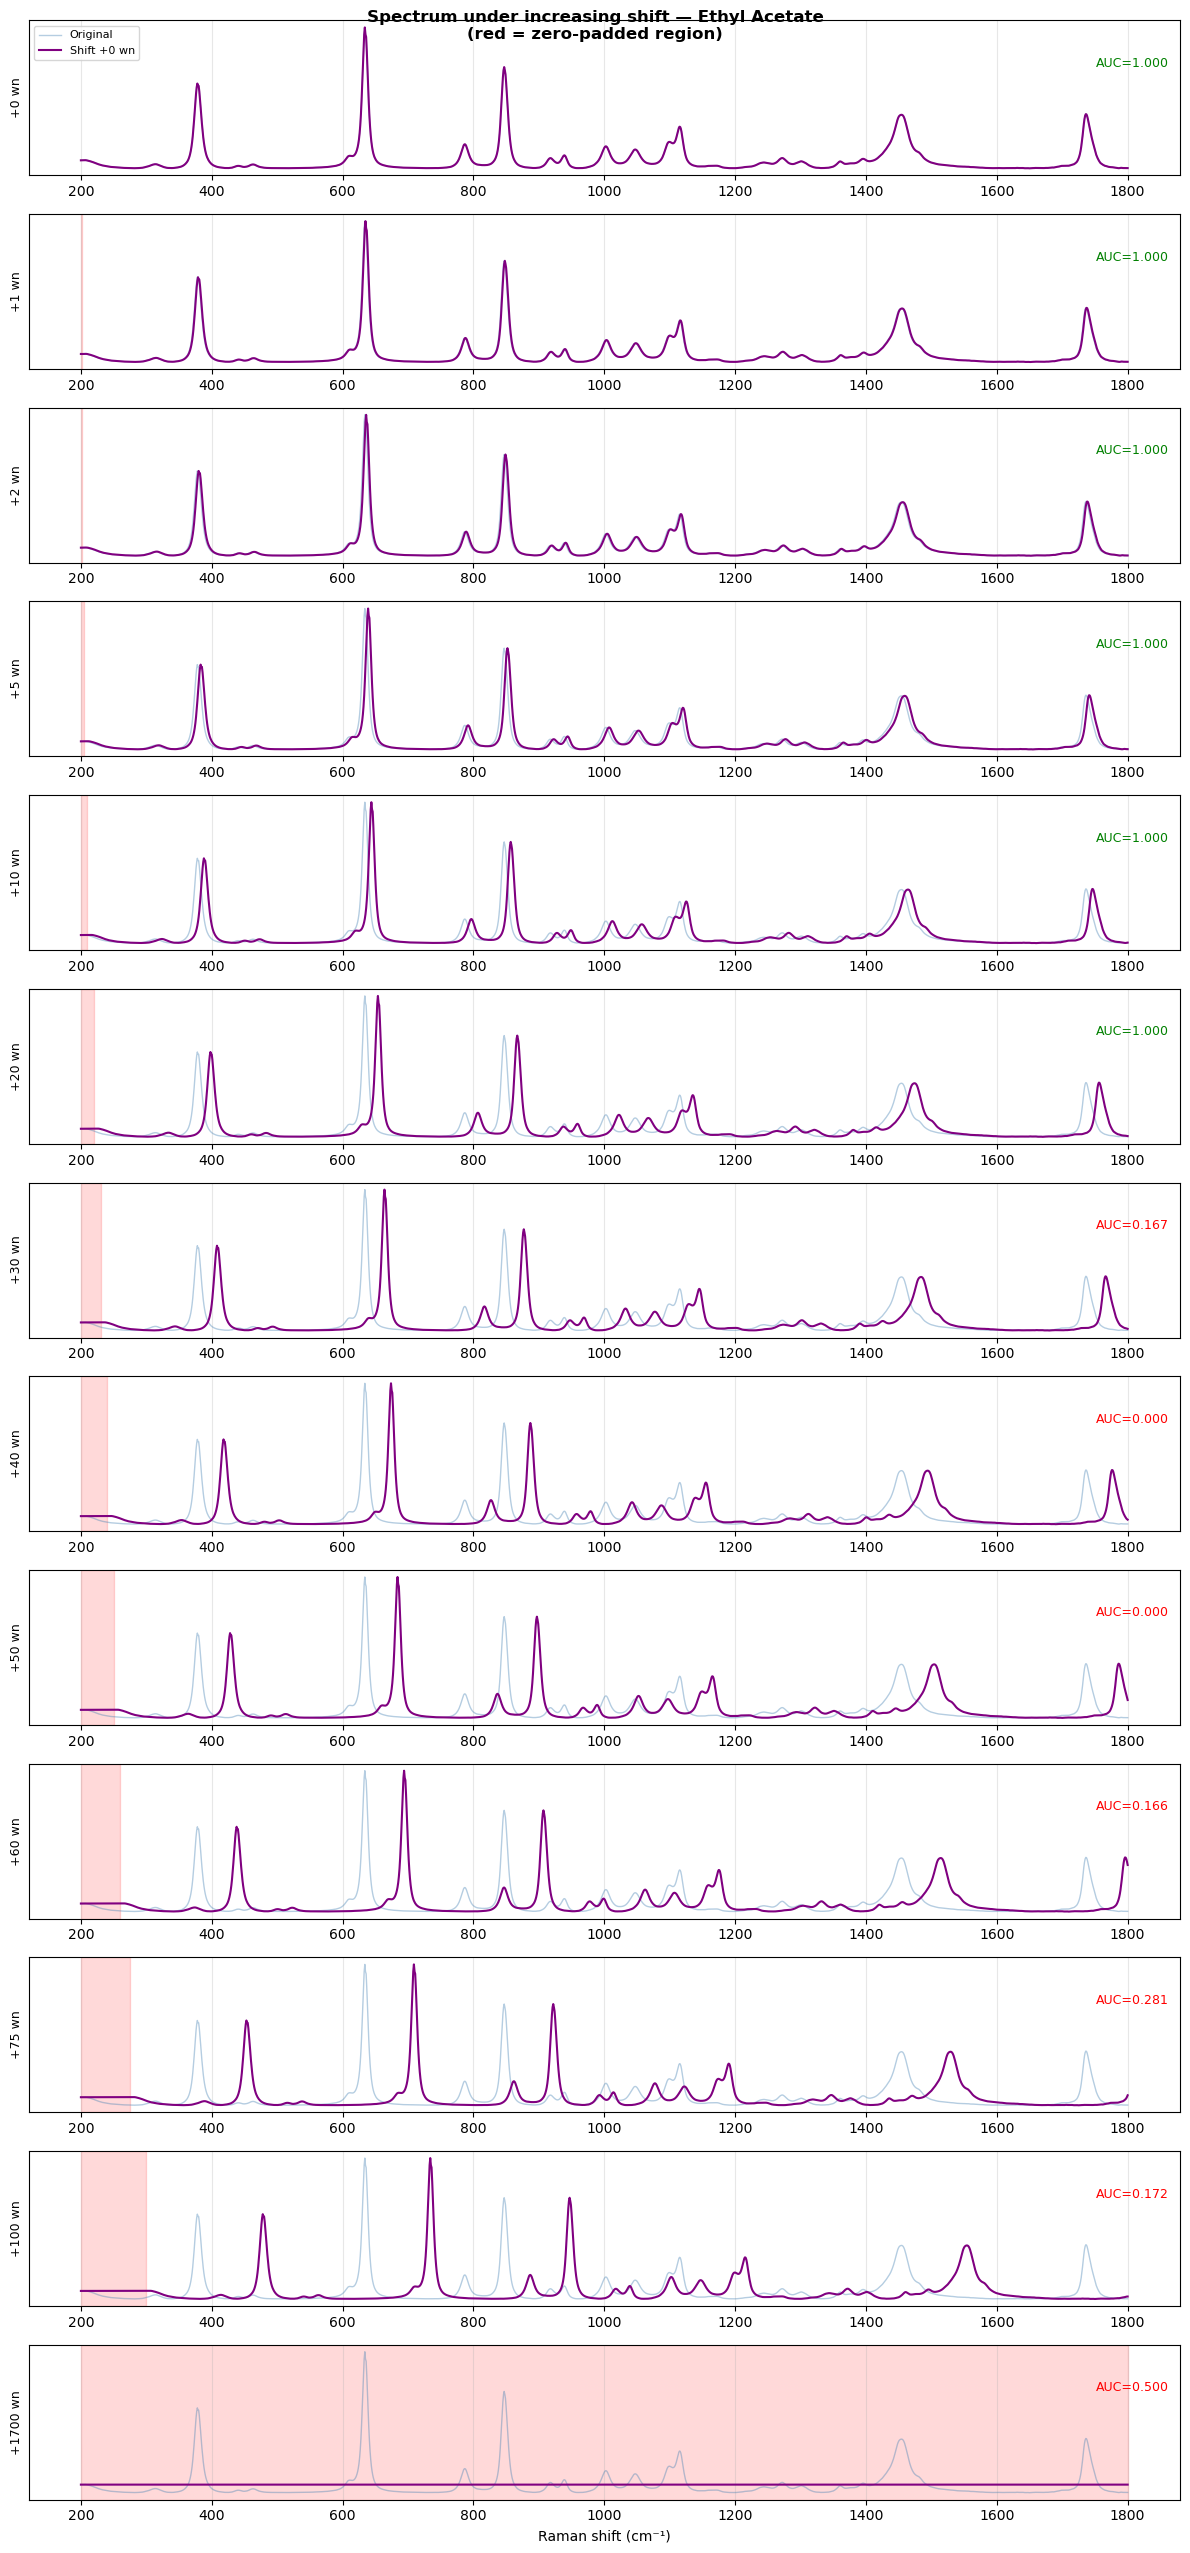

In [45]:
fig, axes = plt.subplots(len(SHIFT_STEPS), 1, figsize=(12, len(SHIFT_STEPS) * 2))

# Pick one example spectrum to show (first test spectrum of first pair)
cls1, cls2 = pairs[0]
mask = np.isin(y, [cls1, cls2])
block_test = test_mask[mask]
X_te_example = X[mask][block_test]
example_spectrum = X_te_example[0]  # just the first test spectrum

for ax, s in zip(axes, SHIFT_STEPS):
    shifted = shift_spectra(example_spectrum.reshape(1, -1), s)[0]
    
    ax.plot(wavenumbers, example_spectrum, color='steelblue', lw=1, 
            alpha=0.4, label='Original')
    ax.plot(wavenumbers, shifted, color='purple', lw=1.5, 
            label=f'Shift +{s} wn')
    
    # shade the zero-padded region
    if s > 0:
        ax.axvspan(wavenumbers[0], wavenumbers[min(s, len(wavenumbers)-1)], 
                   alpha=0.15, color='red', label='Zero-padded')
    
    ax.set_ylabel(f'+{s} wn', fontsize=9)
    ax.set_yticks([])
    ax.grid(True, alpha=0.3)
    
    # annotate with the AUC at this shift
    auc = shift_aucs_fixed[s]
    ax.text(0.99, 0.7, f'AUC={auc:.3f}', transform=ax.transAxes,
            ha='right', fontsize=9,
            color='green' if auc >= 0.999 else 'red')

axes[0].legend(fontsize=8)
axes[-1].set_xlabel('Raman shift (cm⁻¹)')
fig.suptitle(f'Spectrum under increasing shift — {cls1}\n(red = zero-padded region)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

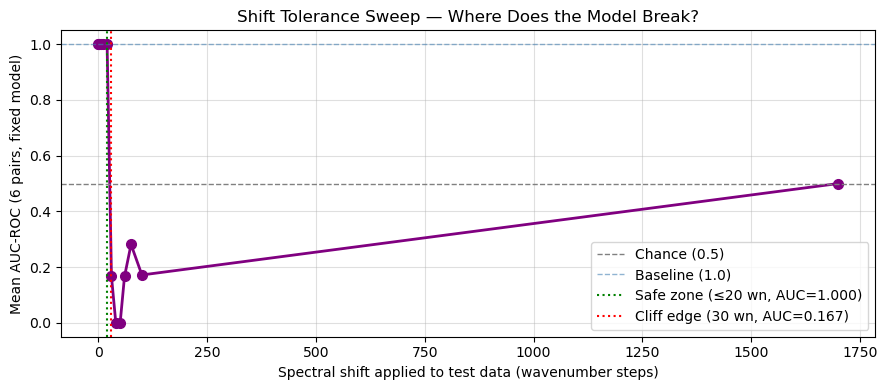

In [46]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(list(shift_aucs_fixed.keys()), list(shift_aucs_fixed.values()),
        'o-', color='purple', lw=2, markersize=7)

ax.axhline(0.5, color='gray',      linestyle='--', lw=1, label='Chance (0.5)')
ax.axhline(1.0, color='steelblue', linestyle='--', lw=1, label='Baseline (1.0)', alpha=0.6)

safe_limit  = max(s for s, a in shift_aucs_fixed.items() if a >= 0.999)
break_point = min(s for s, a in shift_aucs_fixed.items() if a < 0.999)
break_auc   = shift_aucs_fixed[break_point]

ax.axvline(safe_limit,  color='green', linestyle=':', lw=1.5,
           label=f'Safe zone (≤{safe_limit} wn, AUC=1.000)')
ax.axvline(break_point, color='red',   linestyle=':', lw=1.5,
           label=f'Cliff edge ({break_point} wn, AUC={break_auc:.3f})')

ax.set_xlabel('Spectral shift applied to test data (wavenumber steps)')
ax.set_ylabel('Mean AUC-ROC (6 pairs, fixed model)')
ax.set_title('Shift Tolerance Sweep — Where Does the Model Break?')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 10. Shift Diagnostics — Understanding the Breakdown

This section investigates *why* the model breaks at +30 wn and why AUC fluctuates rather than settling at 0.5 after the cliff. Four diagnostic experiments are run.

### 10a. Per-pair AUC breakdown

The mean AUC in Section 9 hides pair-level differences. This shows each pair separately to reveal which pairs cliff earlier or later and which drive the post-cliff fluctuation.

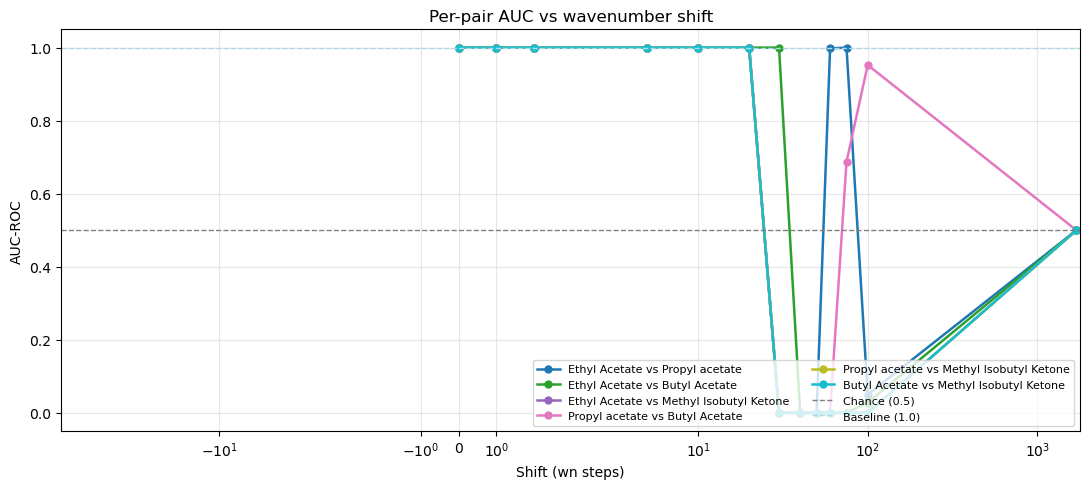


Pair                                              0     1     2     5    10    20    30    40    50    60    75   100  1700
Ethyl Acetate vs Propyl acetate               1.000 1.000 1.000 1.000 1.000 1.000 0.000 0.000 0.000 0.998 1.000 0.050 0.500
Ethyl Acetate vs Butyl Acetate                1.000 1.000 1.000 1.000 1.000 1.000 1.000 0.000 0.000 0.000 0.000 0.028 0.500
Ethyl Acetate vs Methyl Isobutyl Ketone       1.000 1.000 1.000 1.000 1.000 1.000 0.000 0.000 0.000 0.000 0.000 0.000 0.500
Propyl acetate vs Butyl Acetate               1.000 1.000 1.000 1.000 1.000 1.000 0.000 0.000 0.000 0.000 0.687 0.952 0.500
Propyl acetate vs Methyl Isobutyl Ketone      1.000 1.000 1.000 1.000 1.000 1.000 0.000 0.000 0.000 0.000 0.000 0.000 0.500
Butyl Acetate vs Methyl Isobutyl Ketone       1.000 1.000 1.000 1.000 1.000 1.000 0.000 0.000 0.000 0.000 0.000 0.000 0.500


In [47]:
# Per-pair AUC at each shift step
per_pair_shift_aucs = {}

for cls1, cls2 in pairs:
    label = f"{cls1} vs {cls2}"
    model, X_te, y_te, _, _, _, _ = fitted_models[label]
    pair_aucs = []
    for s in SHIFT_STEPS:
        X_te_s = shift_spectra(X_te, s)
        auc    = roc_auc_score(y_te, model.predict_proba(X_te_s)[:, 1])
        pair_aucs.append(auc)
    per_pair_shift_aucs[label] = pair_aucs

fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.cm.tab10(np.linspace(0, 1, len(pairs)))
for i, (label, aucs) in enumerate(per_pair_shift_aucs.items()):
    ax.plot(SHIFT_STEPS, aucs, marker='o', color=cmap[i], label=label, lw=1.8, markersize=5)
ax.axhline(0.5, color='gray', linestyle='--', lw=1, label='Chance (0.5)')
ax.axhline(1.0, color='lightblue', linestyle='--', lw=1, label='Baseline (1.0)')
ax.set_xlabel('Shift (wn steps)')
ax.set_ylabel('AUC-ROC')
ax.set_title('Per-pair AUC vs wavenumber shift')
ax.legend(fontsize=8, ncol=2, loc='lower right')
ax.set_xscale('symlog', linthresh=5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Pair':<45}", end='')
for s in SHIFT_STEPS:
    print(f"{s:>6}", end='')
print()
for label, aucs in per_pair_shift_aucs.items():
    print(f"{label:<45}", end='')
    for a in aucs:
        print(f"{a:>6.3f}", end='')
    print()

### 10b. PCA score drift

Shows where test spectra land in PCA space (PC1 vs PC2) as shift increases, and quantifies the mean L2 drift from the unshifted projection. 

**Key result:** the test cloud drifts sharply between +20 and +30 wn, coinciding exactly with the cliff. At +30 wn both classes collapse into the same region of PCA space — the model cannot separate them not because it is confused, but because the two classes genuinely look identical after the shift. At +60–75 wn the clouds accidentally re-separate, explaining the AUC recovery. At +1700 wn all spectra collapse to a single point (all zeros → identical PCA projection), giving exactly AUC = 0.5.

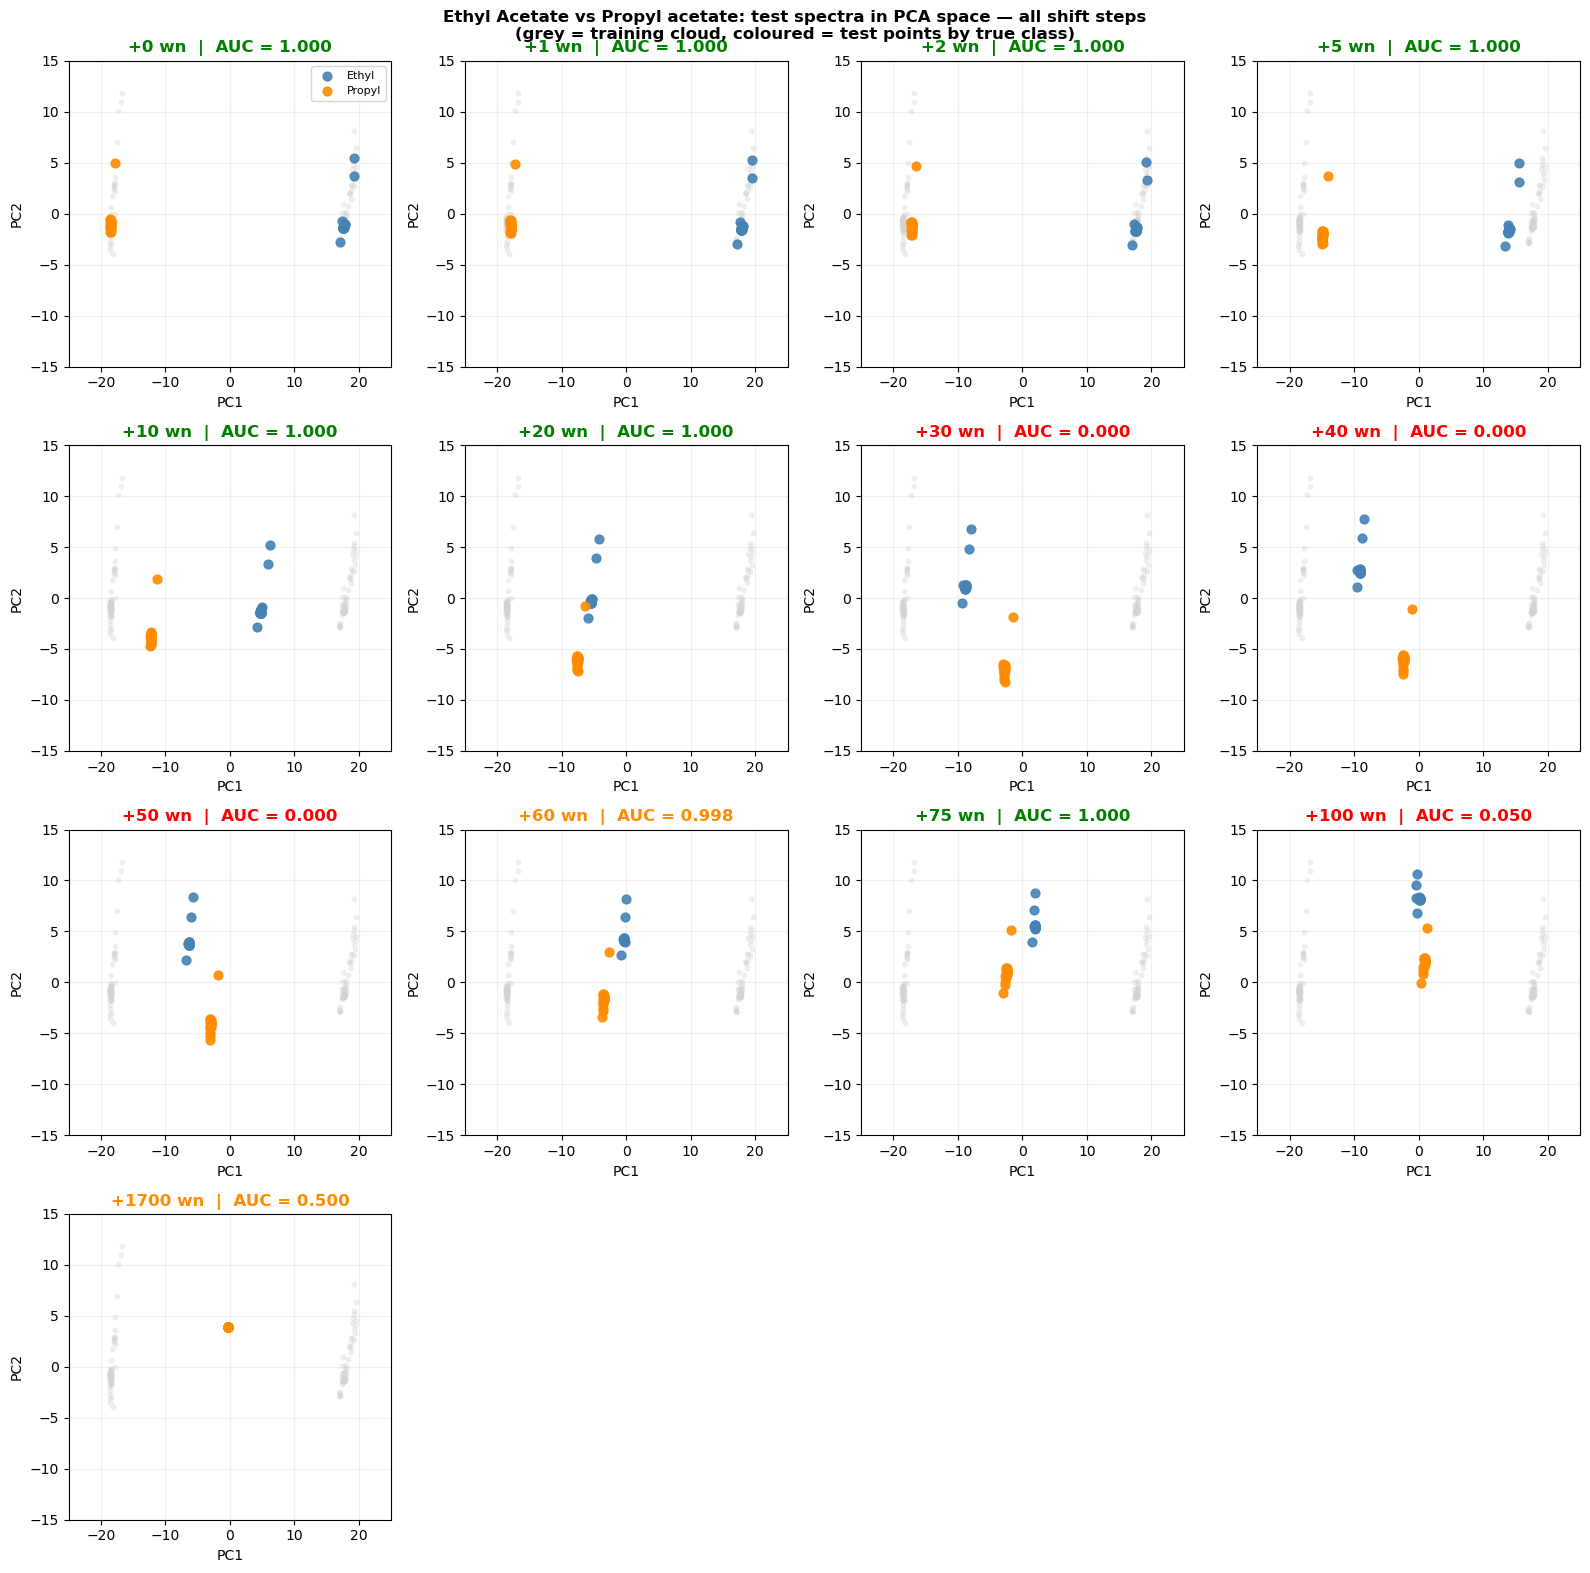

In [48]:
# Reconstruct training data for the focus pair
PAIR_TO_INSPECT = ('Ethyl Acetate', 'Propyl acetate')
label_inspect   = f"{PAIR_TO_INSPECT[0]} vs {PAIR_TO_INSPECT[1]}"

model_i, X_te_i, y_te_i, _, _, cls1_i, cls2_i = fitted_models[label_inspect]
pca_i = model_i.named_steps['pca']

mask_i       = np.isin(y, [cls1_i, cls2_i])
block_test_i = test_mask[mask_i]
X_tr_i       = X[mask_i][~block_test_i]
X_tr_pca     = pca_i.transform(X_tr_i)

# ── PC score grid at all shift steps ─────────────────────────────────────────
inspect_shifts_all = SHIFT_STEPS
n_cols = 4
n_rows = int(np.ceil(len(inspect_shifts_all) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for ax, s in zip(axes, inspect_shifts_all):
    X_te_s   = shift_spectra(X_te_i, s)
    X_te_pca = pca_i.transform(X_te_s)
    auc      = roc_auc_score(y_te_i, model_i.predict_proba(X_te_s)[:, 1])

    ax.scatter(X_tr_pca[:, 0], X_tr_pca[:, 1], c='lightgray', s=10, alpha=0.3, zorder=1)
    for cls_val, col, name in [(1, 'steelblue', cls1_i), (0, 'darkorange', cls2_i)]:
        m = y_te_i == cls_val
        ax.scatter(X_te_pca[m, 0], X_te_pca[m, 1], c=col, s=40, alpha=0.9, zorder=2,
                   label=name.split()[0] if s == 0 else '')

    title_col = 'green' if auc >= 0.999 else ('red' if auc < 0.3 else 'darkorange')
    ax.set_title(f'+{s} wn  |  AUC = {auc:.3f}', color=title_col, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_xlim(-25, 25); ax.set_ylim(-15, 15)
    ax.grid(True, alpha=0.2)

for ax in axes[len(inspect_shifts_all):]:
    ax.set_visible(False)

axes[0].legend(fontsize=8)
fig.suptitle(f'{label_inspect}: test spectra in PCA space — all shift steps\n'
             '(grey = training cloud, coloured = test points by true class)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# # ── L2 drift plot ─────────────────────────────────────────────────────────────
# X_te_ref_pca = pca_i.transform(X_te_i)
# drift_vals   = []
# for s in SHIFT_STEPS[:-1]:
#     X_te_s   = shift_spectra(X_te_i, s)
#     X_te_pca = pca_i.transform(X_te_s)
#     drift_vals.append(np.linalg.norm(X_te_pca - X_te_ref_pca, axis=1).mean())

# fig, ax = plt.subplots(figsize=(9, 4))
# ax.plot(SHIFT_STEPS[:-1], drift_vals, 'o-', color='purple', lw=2)
# ax.axvline(30, color='red', linestyle='--', lw=1.5, label='Cliff edge (~30 wn)')
# ax.set_xlabel('Shift (wn steps)'); ax.set_ylabel('Mean L2 drift in PCA space')
# ax.set_title('How far does the test cloud drift from its unshifted position?')
# ax.legend(); ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

### 10c. Padding strategy comparison

**Hypothesis:** zero-padding the shifted region creates a spurious non-zero signal in PCA space, causing the fluctuating post-cliff AUC instead of a clean floor at 0.5.

**Test:** repeat the shift sweep using mean-padding (fill vacated region with training mean) and noise-padding (fill with Gaussian noise matching training distribution) instead of zeros.

**Result:** all three strategies produce identical behaviour. The fluctuation is **not caused by zero-padding** — it is caused by the PCA geometry (see 10b and 10d).

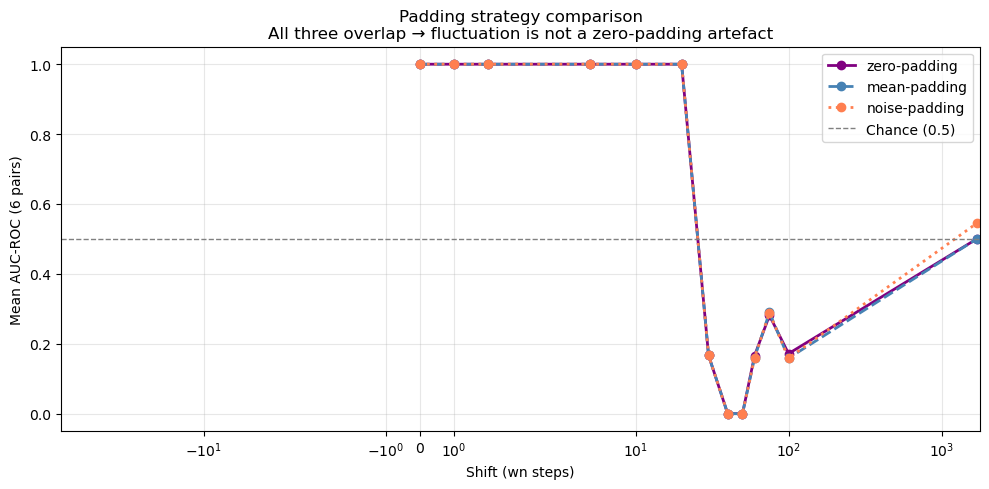


   Shift |     zero |     mean |    noise
----------------------------------------
       0 |    1.000 |    1.000 |    1.000
       1 |    1.000 |    1.000 |    1.000
       2 |    1.000 |    1.000 |    1.000
       5 |    1.000 |    1.000 |    1.000
      10 |    1.000 |    1.000 |    1.000
      20 |    1.000 |    1.000 |    1.000
      30 |    0.167 |    0.167 |    0.167
      40 |    0.000 |    0.000 |    0.000
      50 |    0.000 |    0.000 |    0.000
      60 |    0.166 |    0.161 |    0.161
      75 |    0.281 |    0.289 |    0.288
     100 |    0.172 |    0.159 |    0.159
    1700 |    0.500 |    0.500 |    0.545


In [49]:
# ── Helper functions ─────────────────────────────────────────────────────────
def shift_spectra_padded(X, steps, padding='zero', X_train_ref=None):
    """Shift spectra with selectable padding strategy."""
    if steps == 0:
        return X.copy()
    X_out = np.roll(X, steps, axis=1)
    if steps > 0:
        fill_slice = slice(0, steps)
        X_out[:, :steps] = 0.0
    else:
        fill_slice = slice(steps, None)
        X_out[:, steps:] = 0.0
    if padding == 'mean' and X_train_ref is not None:
        fill_vals = X_train_ref.mean(axis=0)[fill_slice]
        X_out[:, fill_slice] = fill_vals[np.newaxis, :]
    elif padding == 'noise' and X_train_ref is not None:
        mu  = X_train_ref.mean(axis=0)[fill_slice]
        std = X_train_ref.std(axis=0)[fill_slice] + 1e-9
        rng = np.random.default_rng(RANDOM_STATE)
        X_out[:, fill_slice] = rng.normal(mu, std, (len(X), len(mu)))
    return X_out

def get_X_tr(cls1, cls2):
    """Reconstruct training spectra for a pair from global arrays."""
    mask       = np.isin(y, [cls1, cls2])
    block_test = test_mask[mask]
    return X[mask][~block_test]

# ── Sweep ─────────────────────────────────────────────────────────────────────
padding_aucs = {'zero': [], 'mean': [], 'noise': []}
for pad in padding_aucs:
    for s in SHIFT_STEPS:
        aucs = []
        for cls1, cls2 in pairs:
            label    = f"{cls1} vs {cls2}"
            model, X_te, y_te, _, _, _, _ = fitted_models[label]
            X_tr_pad = get_X_tr(cls1, cls2)
            X_te_s   = shift_spectra_padded(X_te, s, padding=pad, X_train_ref=X_tr_pad)
            aucs.append(roc_auc_score(y_te, model.predict_proba(X_te_s)[:, 1]))
        padding_aucs[pad].append(np.mean(aucs))

fig, ax = plt.subplots(figsize=(10, 5))
style = {'zero': ('purple', '-'), 'mean': ('steelblue', '--'), 'noise': ('coral', ':' )}
for pad, aucs in padding_aucs.items():
    col, ls = style[pad]
    ax.plot(SHIFT_STEPS, aucs, marker='o', color=col, linestyle=ls,
            lw=2, markersize=6, label=f'{pad}-padding')
ax.axhline(0.5, color='gray', linestyle='--', lw=1, label='Chance (0.5)')
ax.set_xlabel('Shift (wn steps)'); ax.set_ylabel('Mean AUC-ROC (6 pairs)')
ax.set_title('Padding strategy comparison\nAll three overlap → fluctuation is not a zero-padding artefact')
ax.legend(); ax.set_xscale('symlog', linthresh=5); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Shift':>8} | {'zero':>8} | {'mean':>8} | {'noise':>8}")
print('-' * 40)
for i, s in enumerate(SHIFT_STEPS):
    print(f"{s:>8} | {padding_aucs['zero'][i]:>8.3f} | "
          f"{padding_aucs['mean'][i]:>8.3f} | {padding_aucs['noise'][i]:>8.3f}")

### 10d. PC loading analysis and PC score tracking

**The actual explanation:** PC1 captures 95.9% of variance and its loading peaks at ~380 cm⁻¹ and ~850 cm⁻¹ — exactly the wavenumbers where Ethyl Acetate and Propyl Acetate differ most. At zero shift, PC1 perfectly separates the two classes (Ethyl PC1 ≈ +17, Propyl PC1 ≈ −19). As the shift increases, those peaks move away from the wavenumber positions PC1 was trained on, so both classes converge to the same PC1 score — causing the cliff.

PC2 (1.8% variance) has a different loading pattern and responds differently to the two classes as their peaks slide across the wavenumber axis. At +60–75 wn, PC2 accidentally separates them again (Ethyl PC2 ≈ +5, Propyl PC2 ≈ −6), explaining the AUC recovery. At larger shifts even this breaks down.

**Conclusion:** the post-cliff fluctuation is caused by the two class clouds traversing PCA space non-monotonically as shift increases — sometimes overlapping (AUC → 0), sometimes accidentally re-separating (AUC → 1). Beyond the cliff, AUC values are meaningless. The only reliable result from the sweep is the safe zone: **≤ 20 wn**.

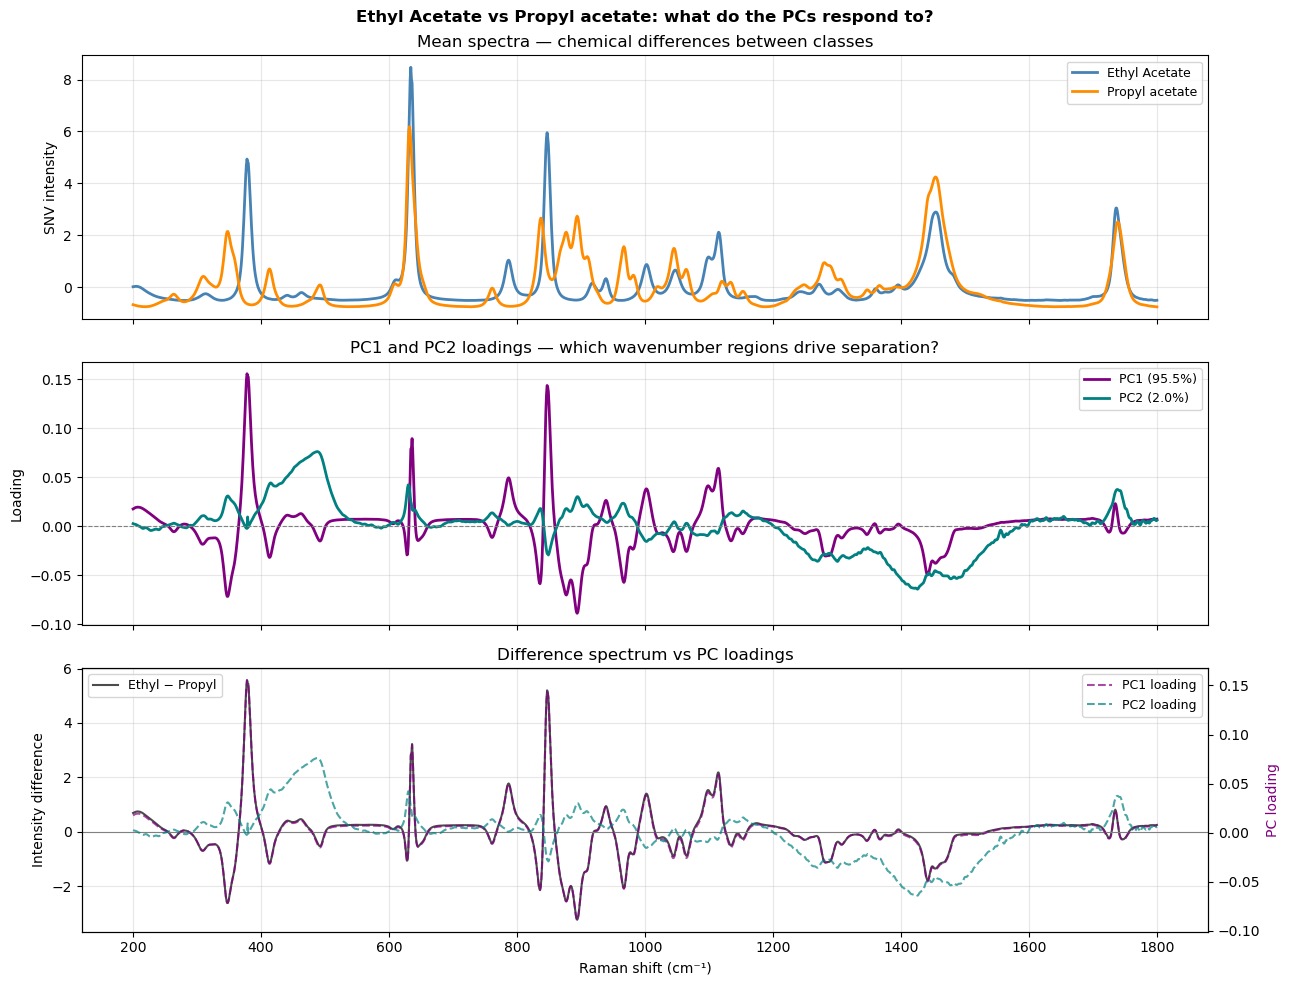

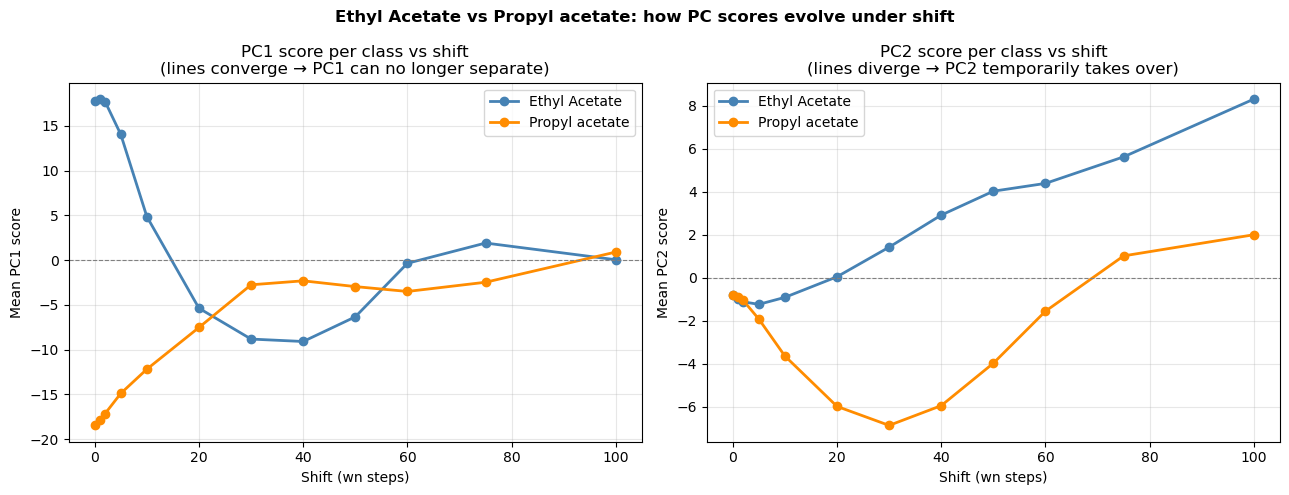

In [50]:
# ── Panel 1–3: mean spectra, PC loadings, difference spectrum ────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for cls_val, col, name in [(1, 'steelblue', cls1_i), (0, 'darkorange', cls2_i)]:
    m = y_te_i == cls_val
    axes[0].plot(wavenumbers, X_te_i[m].mean(axis=0), color=col, lw=2, label=name)
axes[0].set_ylabel('SNV intensity')
axes[0].set_title('Mean spectra — chemical differences between classes')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(wavenumbers, pca_i.components_[0], color='purple', lw=2,
             label=f'PC1 ({pca_i.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].plot(wavenumbers, pca_i.components_[1], color='teal', lw=2,
             label=f'PC2 ({pca_i.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[1].set_ylabel('Loading')
axes[1].set_title('PC1 and PC2 loadings — which wavenumber regions drive separation?')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

diff_spectrum = (X_te_i[y_te_i == 1].mean(axis=0) - X_te_i[y_te_i == 0].mean(axis=0))
ax3a = axes[2]; ax3b = ax3a.twinx()
ax3a.plot(wavenumbers, diff_spectrum, color='black', lw=1.5, alpha=0.7, label='Ethyl − Propyl')
ax3b.plot(wavenumbers, pca_i.components_[0], color='purple', lw=1.5, alpha=0.7,
          linestyle='--', label='PC1 loading')
ax3b.plot(wavenumbers, pca_i.components_[1], color='teal', lw=1.5, alpha=0.7,
          linestyle='--', label='PC2 loading')
ax3a.axhline(0, color='gray', lw=0.8)
ax3a.set_xlabel('Raman shift (cm⁻¹)')
ax3a.set_ylabel('Intensity difference', color='black')
ax3b.set_ylabel('PC loading', color='purple')
ax3a.set_title('Difference spectrum vs PC loadings')
ax3a.legend(fontsize=9, loc='upper left'); ax3b.legend(fontsize=9, loc='upper right')
axes[2].grid(True, alpha=0.3)
fig.suptitle(f'{label_inspect}: what do the PCs respond to?', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Panel 4–5: PC1 and PC2 mean scores per class vs shift ────────────────────
shifts_to_track = [s for s in SHIFT_STEPS if s <= 100]
pc1_cls1, pc1_cls2, pc2_cls1, pc2_cls2 = [], [], [], []

for s in shifts_to_track:
    X_te_s   = shift_spectra(X_te_i, s)
    X_te_pca = pca_i.transform(X_te_s)
    pc1_cls1.append(X_te_pca[y_te_i == 1, 0].mean())
    pc1_cls2.append(X_te_pca[y_te_i == 0, 0].mean())
    pc2_cls1.append(X_te_pca[y_te_i == 1, 1].mean())
    pc2_cls2.append(X_te_pca[y_te_i == 0, 1].mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(shifts_to_track, pc1_cls1, 'o-', color='steelblue',  lw=2, label=cls1_i)
axes[0].plot(shifts_to_track, pc1_cls2, 'o-', color='darkorange', lw=2, label=cls2_i)
axes[0].axhline(0, color='gray', linestyle='--', lw=0.8)
axes[0].set_xlabel('Shift (wn steps)'); axes[0].set_ylabel('Mean PC1 score')
axes[0].set_title('PC1 score per class vs shift\n(lines converge → PC1 can no longer separate)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(shifts_to_track, pc2_cls1, 'o-', color='steelblue',  lw=2, label=cls1_i)
axes[1].plot(shifts_to_track, pc2_cls2, 'o-', color='darkorange', lw=2, label=cls2_i)
axes[1].axhline(0, color='gray', linestyle='--', lw=0.8)
axes[1].set_xlabel('Shift (wn steps)'); axes[1].set_ylabel('Mean PC2 score')
axes[1].set_title('PC2 score per class vs shift\n(lines diverge → PC2 temporarily takes over)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle(f'{label_inspect}: how PC scores evolve under shift', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Raw Spectra — Load & Visual Inspection

Loads the raw (unpreprocessed) spectra from the original CSV. Only wavenumber cropping is applied — no baseline correction, no SNV normalisation. Row count and label order are verified to match the clean dataset so the two can be compared directly.

In [51]:
# --- Load raw data ---
df_raw = pd.read_csv(RAW_CSV)
df_raw = df_raw[df_raw['label'].isin(TARGETS)].reset_index(drop=True)

wavenumbers_raw = df_raw.drop(columns=['label']).columns.astype(float).values
X_raw_all       = df_raw.drop(columns=['label']).values.astype(float)
y_raw           = df_raw['label'].values

# Wavenumber crop only — no baseline correction, no SNV
crop_mask = (wavenumbers_raw >= CROP_MIN) & (wavenumbers_raw <= CROP_MAX)
X_raw     = X_raw_all[:, crop_mask]
wn_raw    = wavenumbers_raw[crop_mask]

print(f"Raw spectra loaded : {X_raw.shape[0]} spectra × {X_raw.shape[1]} wavenumbers")
print(f"Wavenumber range   : {wn_raw[0]:.0f} – {wn_raw[-1]:.0f} cm⁻¹")
print(f"Feature dims match : {X_raw.shape[1] == X.shape[1]}")

# Guard: raw and clean must have same row count and label order
assert len(y_raw) == len(y), f"Row count mismatch: raw={len(y_raw)}, clean={len(y)}"
assert (y_raw == y).all(), "Label order differs between raw and clean CSVs"
print("Row count and label order: OK")

Raw spectra loaded : 428 spectra × 1601 wavenumbers
Wavenumber range   : 200 – 1800 cm⁻¹
Feature dims match : True
Row count and label order: OK


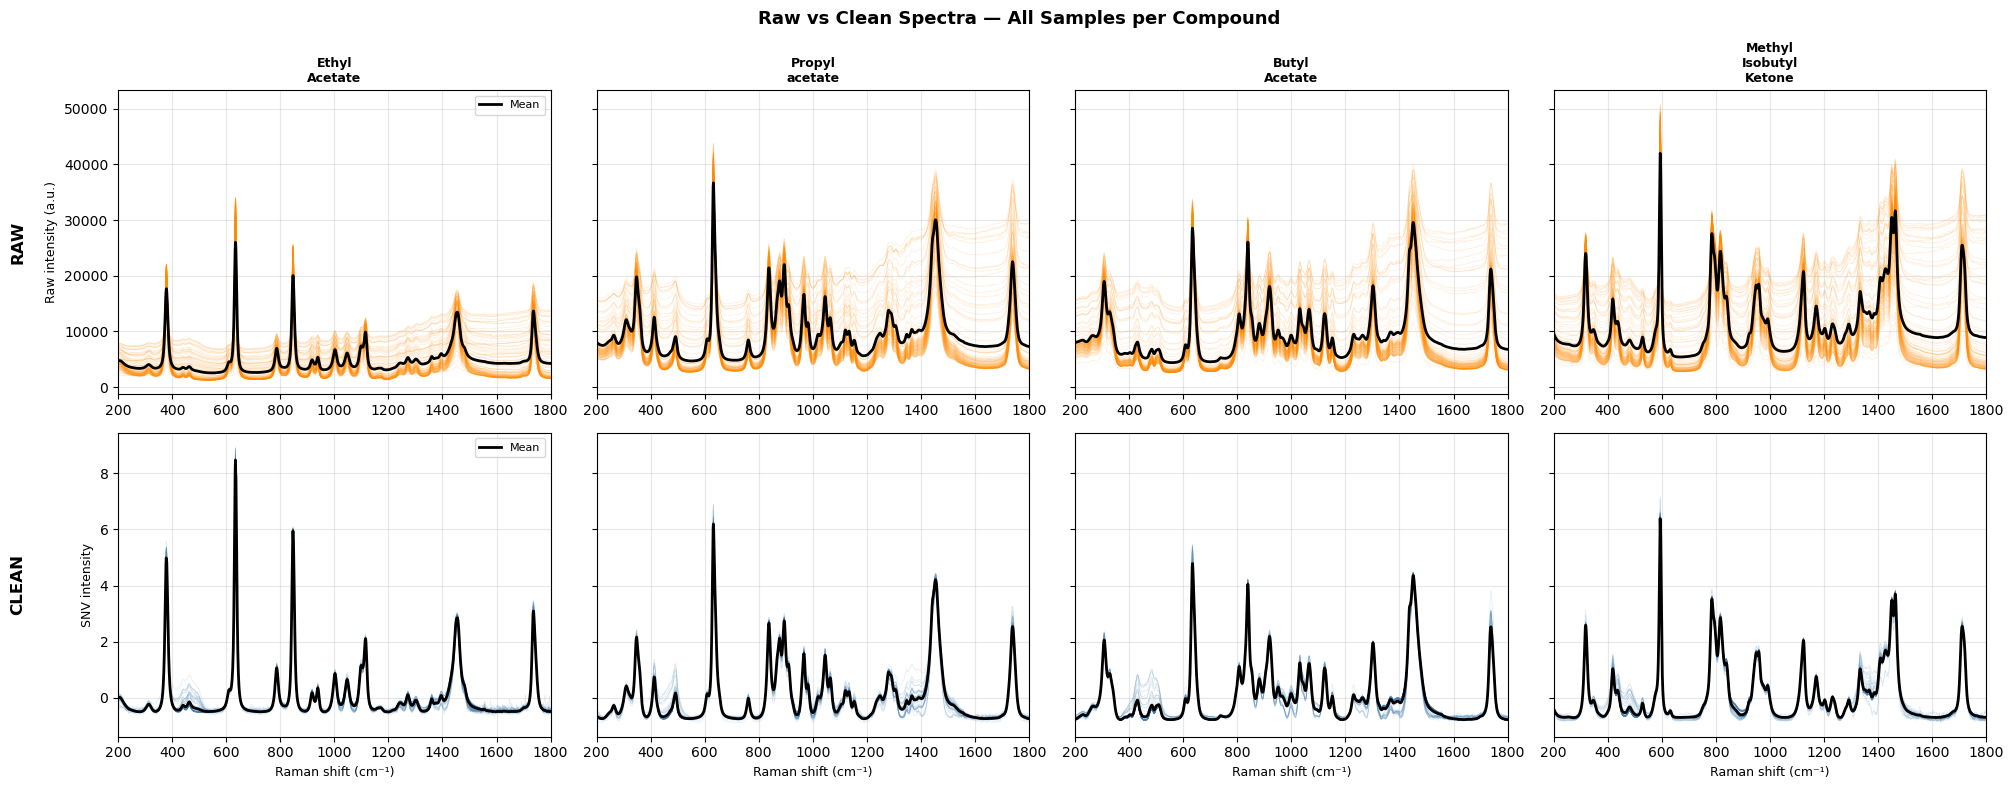

Intensity ranges per compound:
Compound                          Raw min    Raw max  Clean min  Clean max
-----------------------------------------------------------------
Ethyl Acetate                      1204.1    34088.8    -0.6686     8.9521
Propyl acetate                     2647.0    43816.9    -0.9019     6.8966
Butyl Acetate                      2556.5    39989.9    -0.8405     5.4821
Methyl Isobutyl Ketone             2722.4    50834.3    -0.8676     7.1630


In [52]:
# --- Overlay plot: all spectra per compound, raw vs clean ---
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey='row')

for col, (compound, color) in enumerate(zip(TARGETS, COLORS)):
    mask_raw   = y_raw == compound
    mask_clean = y     == compound

    ax = axes[0, col]
    ax.plot(wn_raw, X_raw[mask_raw].T, color='darkorange', alpha=0.15, lw=0.5)
    ax.plot(wn_raw, X_raw[mask_raw].mean(axis=0), color='black', lw=2, label='Mean')
    ax.set_title(compound.replace(' ', '\n'), fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(CROP_MIN, CROP_MAX)
    if col == 0:
        ax.set_ylabel('Raw intensity (a.u.)', fontsize=9)
        ax.legend(fontsize=8)

    ax = axes[1, col]
    ax.plot(wavenumbers, X[mask_clean].T, color='steelblue', alpha=0.15, lw=0.5)
    ax.plot(wavenumbers, X[mask_clean].mean(axis=0), color='black', lw=2, label='Mean')
    ax.set_xlabel('Raman shift (cm⁻¹)', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(CROP_MIN, CROP_MAX)
    if col == 0:
        ax.set_ylabel('SNV intensity', fontsize=9)
        ax.legend(fontsize=8)

axes[0, 0].annotate('RAW',   xy=(-0.25, 0.5), xycoords='axes fraction',
                    fontsize=12, fontweight='bold', va='center', rotation=90)
axes[1, 0].annotate('CLEAN', xy=(-0.25, 0.5), xycoords='axes fraction',
                    fontsize=12, fontweight='bold', va='center', rotation=90)

plt.suptitle('Raw vs Clean Spectra — All Samples per Compound', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Intensity ranges per compound:")
print(f"{'Compound':<30} {'Raw min':>10} {'Raw max':>10} {'Clean min':>10} {'Clean max':>10}")
print("-" * 65)
for compound in TARGETS:
    mr = y_raw == compound
    mc = y     == compound
    print(f"{compound:<30} {X_raw[mr].min():>10.1f} {X_raw[mr].max():>10.1f} "
          f"{X[mc].min():>10.4f} {X[mc].max():>10.4f}")

## 12. Raw Spectra Test — Clean Model on Raw Data

The models trained in Section 5 (on clean data) are applied directly to raw test spectra without retraining. This isolates whether preprocessing is strictly necessary, or whether PCA implicitly absorbs baseline and intensity variation.

In [53]:
print("Results: model trained on CLEAN, tested on RAW\n")
print(f"{'Pair':<45} {'AUC (clean test)':>18} {'AUC (raw test)':>16}")
print("-" * 82)

raw_results = {}

for cls1, cls2 in pairs:
    label = f"{cls1} vs {cls2}"
    model, _, _, _, _, _, _ = fitted_models[label]

    mask_raw          = np.isin(y_raw, [cls1, cls2])
    df_raw_pair       = df_raw[mask_raw].copy()
    df_raw_pair['si'] = df_raw_pair.groupby('label').cumcount()
    test_mask_raw     = (df_raw_pair['si'] % 5 == 0).values

    X_raw_pair = X_raw[mask_raw]
    y_raw_bin  = (y_raw[mask_raw] == cls1).astype(int)
    X_raw_te   = X_raw_pair[test_mask_raw]
    y_raw_te   = y_raw_bin[test_mask_raw]

    y_prob_raw = model.predict_proba(X_raw_te)[:, 1]
    auc_raw    = roc_auc_score(y_raw_te, y_prob_raw)

    raw_results[label] = auc_raw
    print(f"{label:<45} {results[label]['AUC']:>18.3f} {auc_raw:>16.3f}")

print("-" * 82)
print(f"{'Mean':<45} "
      f"{np.mean([results[f'{c1} vs {c2}']['AUC'] for c1, c2 in pairs]):>18.3f} "
      f"{np.mean(list(raw_results.values())):>16.3f}")

Results: model trained on CLEAN, tested on RAW

Pair                                            AUC (clean test)   AUC (raw test)
----------------------------------------------------------------------------------
Ethyl Acetate vs Propyl acetate                            1.000            0.500
Ethyl Acetate vs Butyl Acetate                             1.000            0.500
Ethyl Acetate vs Methyl Isobutyl Ketone                    1.000            0.500
Propyl acetate vs Butyl Acetate                            1.000            0.500
Propyl acetate vs Methyl Isobutyl Ketone                   1.000            0.500
Butyl Acetate vs Methyl Isobutyl Ketone                    1.000            0.500
----------------------------------------------------------------------------------
Mean                                                       1.000            0.500


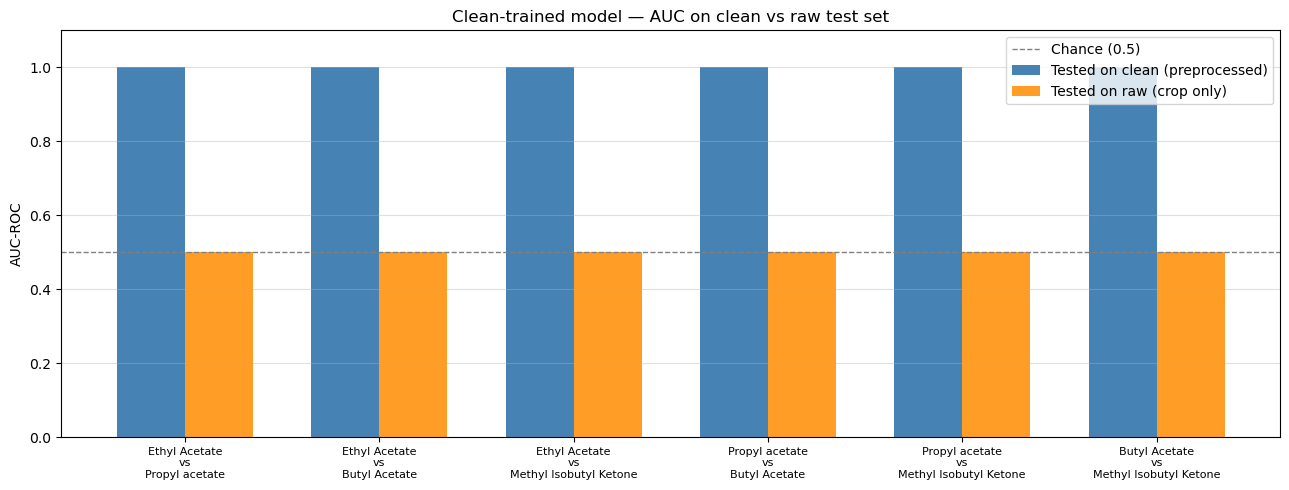

In [54]:
# Bar chart: clean test vs raw test AUC
labels_plot = list(raw_results.keys())
clean_aucs  = [results[l]['AUC'] for l in labels_plot]
raw_aucs    = [raw_results[l]    for l in labels_plot]

x = np.arange(len(labels_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, clean_aucs, w, label='Tested on clean (preprocessed)', color='steelblue')
ax.bar(x + w/2, raw_aucs,   w, label='Tested on raw (crop only)',       color='darkorange', alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--', lw=1, label='Chance (0.5)')
ax.set_xticks(x)
ax.set_xticklabels([l.replace(' vs ', '\nvs\n') for l in labels_plot], fontsize=8)
ax.set_ylabel('AUC-ROC')
ax.set_title('Clean-trained model — AUC on clean vs raw test set')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 13. Raw Pipeline — Train and Evaluate Entirely on Raw Data

A fresh pipeline is trained from scratch on raw spectra and evaluated on raw test spectra. N_PCA is computed independently from the raw training data variance — not inherited from the clean pipeline.

**Key finding:** the raw pipeline matches the clean pipeline (AUC = 1.0 across all pairs) despite needing only 5 PCs vs 42. PCA implicitly absorbs the baseline offset and intensity variation that SNV removes explicitly.

The clean pipeline is preferred for deployment because:
- Its 42 PCs represent chemical signal, not measurement artefacts
- PC loadings are interpretable — peaks correspond to real Raman bands
- It is robust to baseline changes across sessions or instruments
- A raw model trained on one instrument's baseline would likely fail on another

In [55]:
# Guards
assert set(np.unique(y_raw)) == set(TARGETS), f"y_raw contains unexpected classes: {np.unique(y_raw)}"
assert X_raw.shape[1] == X.shape[1], f"Feature mismatch: raw={X_raw.shape[1]}, clean={X.shape[1]}"

print("=== Raw Pipeline: Train and Evaluate ===\n")
print(f"{'Pair':<45} {'AUC (clean)':>12} {'AUC (raw)':>12} {'Clean PCs':>10} {'Raw PCs':>8}")
print("-" * 92)

raw_model_results = {}
raw_fitted_models = {}

for cls1, cls2 in pairs:
    label = f"{cls1} vs {cls2}"

    # Subset raw data to this pair
    mask_raw   = np.isin(y_raw, [cls1, cls2])
    X_raw_pair = X_raw[mask_raw]
    y_raw_bin  = (y_raw[mask_raw] == cls1).astype(int)

    # Reconstruct block holdout mask — same every-5th-per-class logic as Section 3
    df_raw_pair       = df_raw[mask_raw].copy().reset_index(drop=True)
    df_raw_pair['si'] = df_raw_pair.groupby('label').cumcount()
    test_mask_raw     = (df_raw_pair['si'] % 5 == 0).values

    X_raw_tr = X_raw_pair[~test_mask_raw]
    X_raw_te = X_raw_pair[test_mask_raw]
    y_raw_tr = y_raw_bin[~test_mask_raw]
    y_raw_te = y_raw_bin[test_mask_raw]

    # Verify split sizes match the clean split
    mask_clean       = np.isin(y, [cls1, cls2])
    block_test_clean = test_mask[mask_clean]
    assert (~test_mask_raw).sum() == (~block_test_clean).sum(), f"Train size mismatch for {label}"
    assert test_mask_raw.sum()    == block_test_clean.sum(),    f"Test size mismatch for {label}"

    # Calculate N_PCA from raw training data variance independently
    _pca_raw    = PCA().fit(X_raw_tr)
    _cumvar_raw = np.cumsum(_pca_raw.explained_variance_ratio_)
    n_raw_pca   = min(int(np.searchsorted(_cumvar_raw, 0.9999)) + 1, len(X_raw_tr) - 2)

    raw_pipe = clone(pipe).set_params(pca__n_components=n_raw_pca)
    raw_pipe.fit(X_raw_tr, y_raw_tr)

    y_prob_raw = raw_pipe.predict_proba(X_raw_te)[:, 1]
    y_pred_raw = raw_pipe.predict(X_raw_te)
    auc_raw    = roc_auc_score(y_raw_te, y_prob_raw)
    ba_raw     = balanced_accuracy_score(y_raw_te, y_pred_raw)

    raw_model_results[label] = {'AUC': auc_raw, 'BA': ba_raw}
    raw_fitted_models[label] = raw_pipe

    clean_npca = fitted_models[label][0].named_steps['pca'].n_components_
    print(f"{label:<45} {results[label]['AUC']:>12.3f} {auc_raw:>12.3f} {clean_npca:>10} {n_raw_pca:>8}")

print("-" * 92)
print(f"{'Mean':<45} "
      f"{np.mean([results[l]['AUC'] for l in raw_model_results]):>12.3f} "
      f"{np.mean([raw_model_results[l]['AUC'] for l in raw_model_results]):>12.3f}")

=== Raw Pipeline: Train and Evaluate ===

Pair                                           AUC (clean)    AUC (raw)  Clean PCs  Raw PCs
--------------------------------------------------------------------------------------------
Ethyl Acetate vs Propyl acetate                      1.000        1.000         48        5
Ethyl Acetate vs Butyl Acetate                       1.000        1.000         45        5
Ethyl Acetate vs Methyl Isobutyl Ketone              1.000        1.000         34        5
Propyl acetate vs Butyl Acetate                      1.000        1.000         58        5
Propyl acetate vs Methyl Isobutyl Ketone             1.000        1.000         20        5
Butyl Acetate vs Methyl Isobutyl Ketone              1.000        1.000         26        5
--------------------------------------------------------------------------------------------
Mean                                                 1.000        1.000


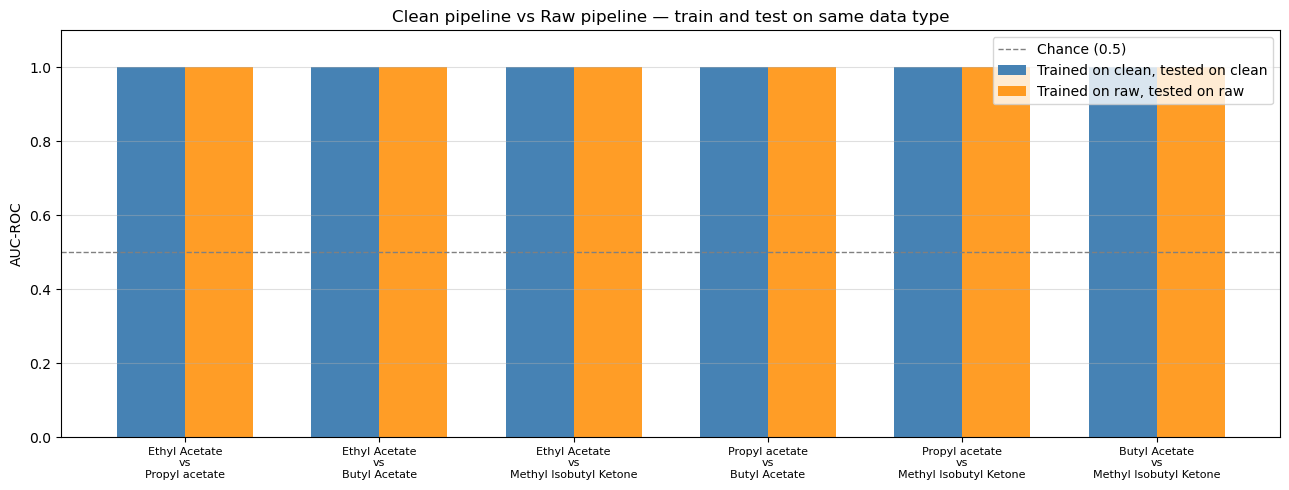

In [56]:
# Bar chart: clean pipeline vs raw pipeline
labels_plot = list(raw_model_results.keys())
clean_aucs  = [results[l]['AUC'] for l in labels_plot]
raw_aucs    = [raw_model_results[l]['AUC'] for l in labels_plot]

x = np.arange(len(labels_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, clean_aucs, w, label='Trained on clean, tested on clean', color='steelblue')
ax.bar(x + w/2, raw_aucs,   w, label='Trained on raw, tested on raw',     color='darkorange', alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--', lw=1, label='Chance (0.5)')
ax.set_xticks(x)
ax.set_xticklabels([l.replace(' vs ', '\nvs\n') for l in labels_plot], fontsize=8)
ax.set_ylabel('AUC-ROC')
ax.set_title('Clean pipeline vs Raw pipeline — train and test on same data type')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

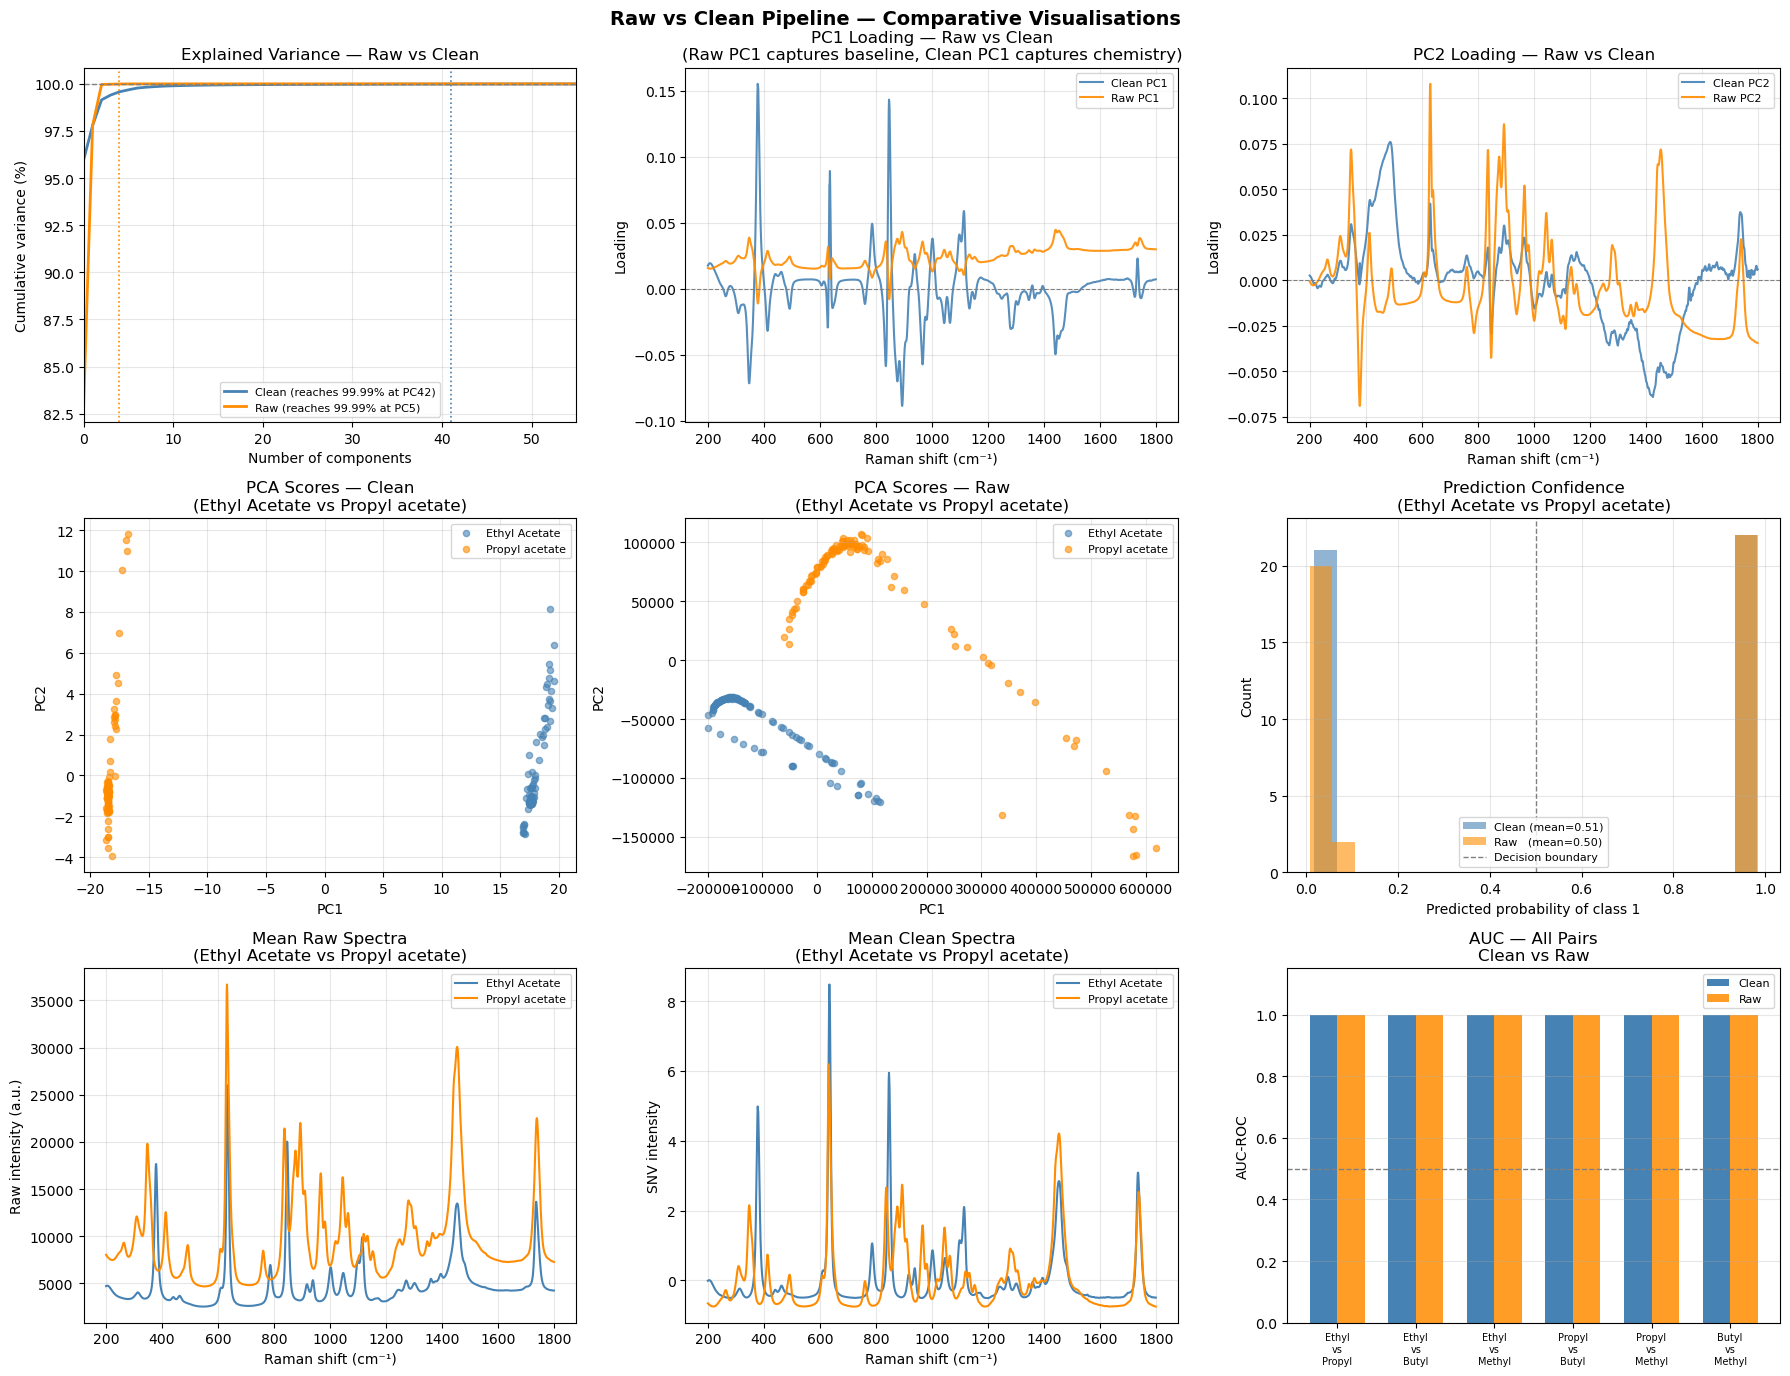

In [57]:
# === Visualising the Raw vs Clean Pipeline ===

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Raw vs Clean Pipeline — Comparative Visualisations', 
             fontsize=14, fontweight='bold')

# ─── Pick one pair for single-pair plots ───────────────────────────────────
focus_cls1, focus_cls2 = 'Ethyl Acetate', 'Propyl acetate'
focus_label = f"{focus_cls1} vs {focus_cls2}"

# Retrieve clean model and raw model for this pair
clean_model = fitted_models[focus_label][0]
raw_model   = raw_fitted_models[focus_label]

# Reconstruct full pair data (train + test) for PCA score plots
mask_clean   = np.isin(y, [focus_cls1, focus_cls2])
X_pair_clean = X[mask_clean]
y_pair_clean = y[mask_clean]

mask_raw_pair = np.isin(y_raw, [focus_cls1, focus_cls2])
X_pair_raw    = X_raw[mask_raw_pair]
y_pair_raw    = y_raw[mask_raw_pair]

# ─── Panel 1: Cumulative explained variance ────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)

# Fit full PCA on entire pair (train+test) for illustration only
_pca_c = PCA().fit(X_pair_clean)
_pca_r = PCA().fit(X_pair_raw)
_cumvar_c = np.cumsum(_pca_c.explained_variance_ratio_) * 100
_cumvar_r = np.cumsum(_pca_r.explained_variance_ratio_) * 100

ax1.plot(_cumvar_c[:60], color='steelblue', lw=2, label=f'Clean (reaches 99.99% at PC42)')
ax1.plot(_cumvar_r[:60], color='darkorange', lw=2, label=f'Raw (reaches 99.99% at PC5)')
ax1.axhline(99.99, color='gray', linestyle='--', lw=1)
ax1.axvline(4,  color='darkorange', linestyle=':', lw=1.2)  # PC5 (0-indexed: 4)
ax1.axvline(41, color='steelblue',  linestyle=':', lw=1.2)  # PC42 (0-indexed: 41)
ax1.set_xlabel('Number of components')
ax1.set_ylabel('Cumulative variance (%)')
ax1.set_title('Explained Variance — Raw vs Clean')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 55)

# ─── Panel 2: PC1 loading — raw vs clean ──────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)

clean_pc1 = clean_model.named_steps['pca'].components_[0]
raw_pc1   = raw_model.named_steps['pca'].components_[0]

ax2.plot(wavenumbers, clean_pc1, color='steelblue', lw=1.5, alpha=0.9, label='Clean PC1')
ax2.plot(wn_raw,      raw_pc1,   color='darkorange', lw=1.5, alpha=0.9, label='Raw PC1')
ax2.axhline(0, color='gray', lw=0.8, linestyle='--')
ax2.set_xlabel('Raman shift (cm⁻¹)')
ax2.set_ylabel('Loading')
ax2.set_title('PC1 Loading — Raw vs Clean\n(Raw PC1 captures baseline, Clean PC1 captures chemistry)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ─── Panel 3: PC2 loading — raw vs clean ──────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)

clean_pc2 = clean_model.named_steps['pca'].components_[1]
raw_pc2   = raw_model.named_steps['pca'].components_[1]

ax3.plot(wavenumbers, clean_pc2, color='steelblue', lw=1.5, alpha=0.9, label='Clean PC2')
ax3.plot(wn_raw,      raw_pc2,   color='darkorange', lw=1.5, alpha=0.9, label='Raw PC2')
ax3.axhline(0, color='gray', lw=0.8, linestyle='--')
ax3.set_xlabel('Raman shift (cm⁻¹)')
ax3.set_ylabel('Loading')
ax3.set_title('PC2 Loading — Raw vs Clean')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# ─── Panel 4: PCA score plot — clean ──────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)

scores_clean = clean_model.named_steps['pca'].transform(X_pair_clean)
colors_map   = {focus_cls1: 'steelblue', focus_cls2: 'darkorange'}

for cls, col in colors_map.items():
    m = y_pair_clean == cls
    ax4.scatter(scores_clean[m, 0], scores_clean[m, 1],
                c=col, alpha=0.6, s=20, label=cls)

ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
ax4.set_title(f'PCA Scores — Clean\n({focus_label})')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# ─── Panel 5: PCA score plot — raw ────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)

scores_raw = raw_model.named_steps['pca'].transform(X_pair_raw)

for cls, col in colors_map.items():
    m = y_pair_raw == cls
    ax5.scatter(scores_raw[m, 0], scores_raw[m, 1],
                c=col, alpha=0.6, s=20, label=cls)

ax5.set_xlabel('PC1')
ax5.set_ylabel('PC2')
ax5.set_title(f'PCA Scores — Raw\n({focus_label})')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# ─── Panel 6: Prediction confidence — clean vs raw ────────────────────────
ax6 = fig.add_subplot(3, 3, 6)

# Clean model probabilities on clean test set
_, X_te_clean, y_te_clean, _, y_prob_clean, _, _ = fitted_models[focus_label]

# Raw model probabilities on raw test set
mask_raw_pair2    = np.isin(y_raw, [focus_cls1, focus_cls2])
df_raw_pair2      = df_raw[mask_raw_pair2].copy().reset_index(drop=True)
df_raw_pair2['si'] = df_raw_pair2.groupby('label').cumcount()
test_mask_raw2    = (df_raw_pair2['si'] % 5 == 0).values
X_raw_te2         = X_raw[mask_raw_pair2][test_mask_raw2]
y_prob_raw_focus  = raw_model.predict_proba(X_raw_te2)[:, 1]

ax6.hist(y_prob_clean, bins=20, alpha=0.6, color='steelblue',
         label=f'Clean (mean={y_prob_clean.mean():.2f})')
ax6.hist(y_prob_raw_focus, bins=20, alpha=0.6, color='darkorange',
         label=f'Raw   (mean={y_prob_raw_focus.mean():.2f})')
ax6.axvline(0.5, color='gray', linestyle='--', lw=1, label='Decision boundary')
ax6.set_xlabel('Predicted probability of class 1')
ax6.set_ylabel('Count')
ax6.set_title(f'Prediction Confidence\n({focus_label})')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# ─── Panel 7: Mean spectrum per class — raw ───────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)

for cls, col in [('steelblue', focus_cls1), ('darkorange', focus_cls2)]:
    m = y_raw == col
    ax7.plot(wn_raw, X_raw[m].mean(axis=0), color=cls, lw=1.5, label=col)

ax7.set_xlabel('Raman shift (cm⁻¹)')
ax7.set_ylabel('Raw intensity (a.u.)')
ax7.set_title(f'Mean Raw Spectra\n({focus_label})')
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

# ─── Panel 8: Mean spectrum per class — clean ─────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)

for cls, col in [('steelblue', focus_cls1), ('darkorange', focus_cls2)]:
    m = y == col
    ax8.plot(wavenumbers, X[m].mean(axis=0), color=cls, lw=1.5, label=col)

ax8.set_xlabel('Raman shift (cm⁻¹)')
ax8.set_ylabel('SNV intensity')
ax8.set_title(f'Mean Clean Spectra\n({focus_label})')
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.3)

# ─── Panel 9: AUC comparison all pairs ────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)

pair_labels  = [f"{c1.split()[0]}\nvs\n{c2.split()[0]}" for c1, c2 in pairs]
clean_aucs_r = [results[f"{c1} vs {c2}"]['AUC'] for c1, c2 in pairs]
raw_aucs_r   = [raw_model_results[f"{c1} vs {c2}"]['AUC'] for c1, c2 in pairs]

x = np.arange(len(pairs))
w = 0.35
ax9.bar(x - w/2, clean_aucs_r, w, color='steelblue', label='Clean')
ax9.bar(x + w/2, raw_aucs_r,   w, color='darkorange', alpha=0.85, label='Raw')
ax9.axhline(0.5, color='gray', linestyle='--', lw=1)
ax9.set_xticks(x)
ax9.set_xticklabels(pair_labels, fontsize=7)
ax9.set_ylabel('AUC-ROC')
ax9.set_ylim(0, 1.15)
ax9.set_title('AUC — All Pairs\nClean vs Raw')
ax9.legend(fontsize=8)
ax9.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()